#Lexikon alapú szentiment analízis


##EDA - Feltáró adatelemnzés

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Libraries for Basic NLP Preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("hf://datasets/Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup/archive.zip") #GJ
#movie_reviews = pd.read_csv("IMDB_Dataset.csv") #KR

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1. DATAFRAME ÁTTEKINTÉS
Alak (sor, oszlop): (50000, 2)

Oszlopok:
['review', 'sentiment']

Adattípusok:
review       object
sentiment    object
dtype: object

Hiányzó értékek:
review       0
sentiment    0
dtype: int64

Duplikált sorok száma: 418
Duplikált review-k száma: 418

Első 3 sor:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive



2. CÉLVÁLTOZÓ ELOSZLÁSA


,count,percent
sentiment,,
positive,25000,50.0
negative,25000,50.0


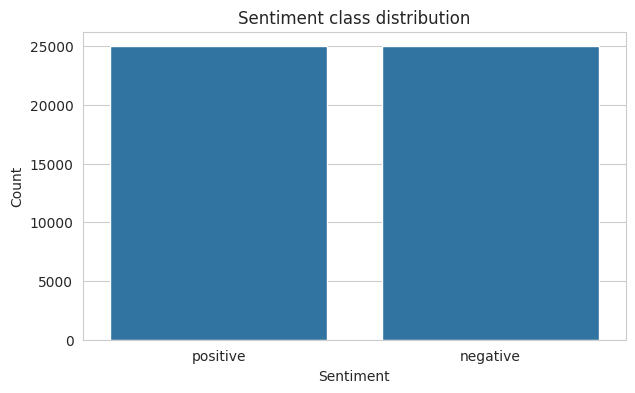


3. SZÖVEGHOSSZ JELLEMZŐK


,count,mean,std,min,25%,50%,75%,max
char_len,50000.0,1309.43102,989.728014,32.0,699.0,970.0,1590.25,13704.0
word_count_raw,50000.0,231.15694,171.343997,4.0,126.0,173.0,280.00,2470.0
token_count_clean,50000.0,234.18710,173.516096,6.0,128.0,176.0,284.00,2494.0


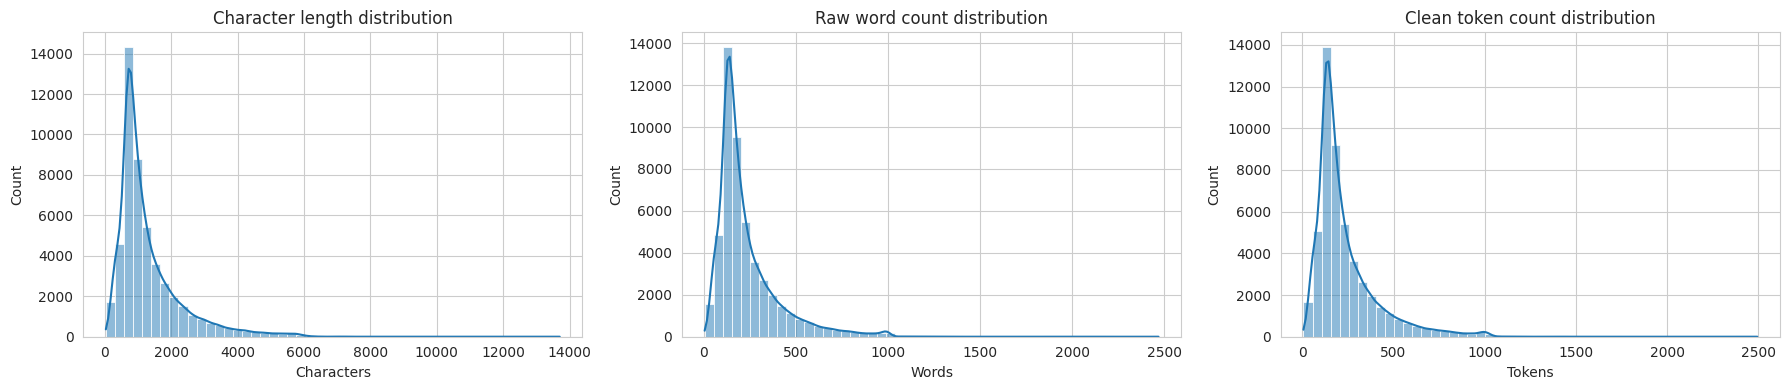


4. SZÖVEGHOSSZ SENTIMENT SZERINT


char_len                                word_count_raw         \
                 mean median          std min    max           mean median   
sentiment                                                                    
negative   1294.06436  973.0   945.892669  32   8969      229.46456  174.0   
positive   1324.79768  968.0  1031.492627  65  13704      232.84932  172.0   

                                token_count_clean                               
                  std min   max              mean median         std min   max  
sentiment                                                                       
negative   164.947795   4  1522         232.65904  176.5  167.213549   6  1539  
positive   177.497046  10  2470         235.71516  175.0  179.587957  10  2494

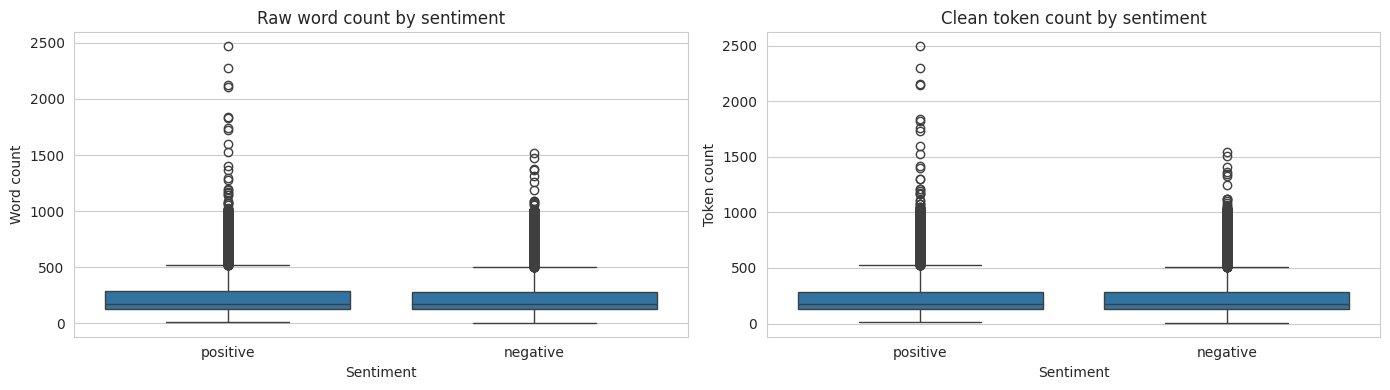


5. TOKEN ELEMZÉS


,count,mean,std,min,25%,50%,75%,max
token_count_clean,50000.0,234.187100,173.516096,6.0,128.000000,176.0,284.000000,2494.000000
stopword_count,50000.0,116.033980,85.642658,0.0,64.000000,89.0,140.000000,1209.000000
non_stopword_count,50000.0,118.153120,89.412558,3.0,63.000000,88.0,144.000000,1422.000000
stopword_ratio,50000.0,0.496879,0.049196,0.0,0.466667,0.5,0.529412,0.692308


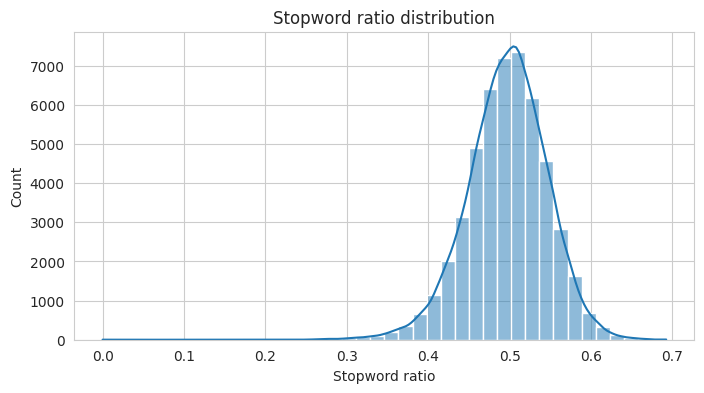


6. LEGGYAKORIBB SZAVAK
Top 20 token (stopwordökkel együtt):


,token,count
0,the,668010
1,and,324446
2,a,323062
3,of,289416
4,to,268126
5,is,211093
6,it,190862
7,in,186788
8,i,175646
9,this,151002


Top 20 token (stopwordök nélkül):


,token,count
0,movie,87973
1,film,79708
2,one,53603
3,like,40172
4,good,29753
5,time,25110
6,even,24872
7,would,24602
8,story,23121
9,really,23095


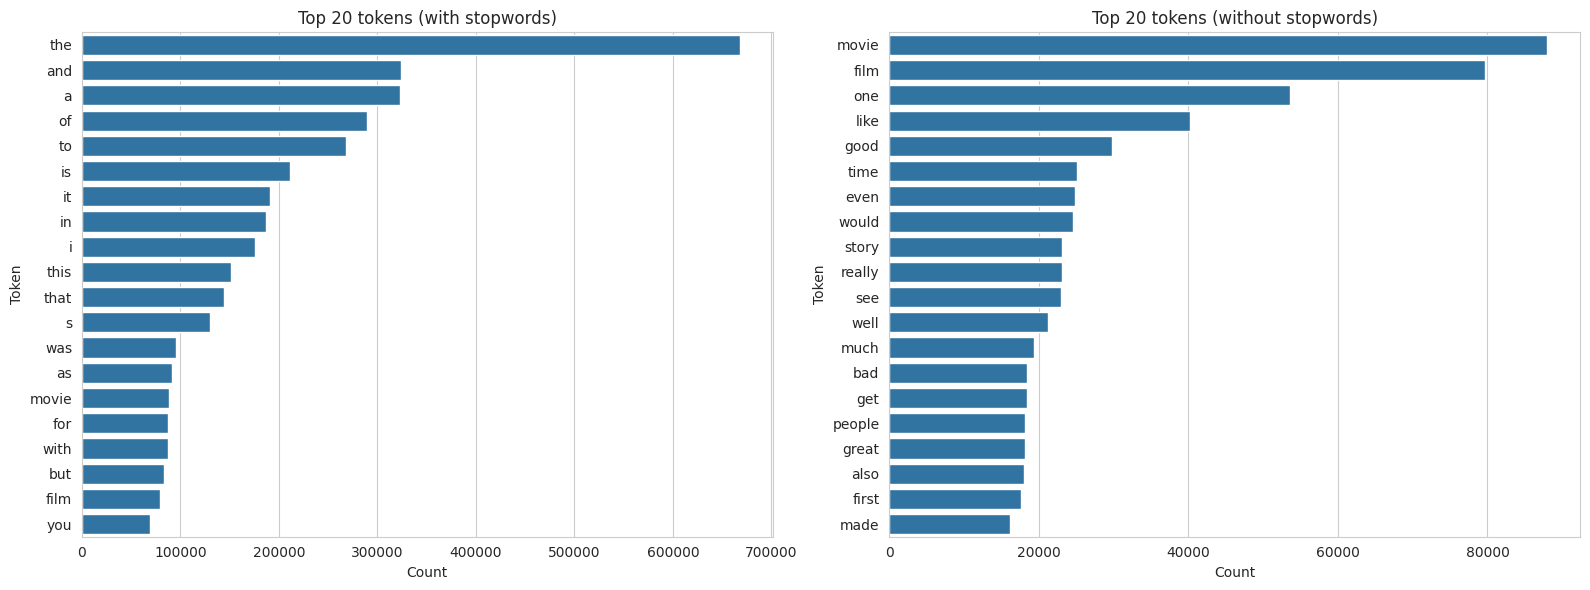


7. LEGGYAKORIBB SZAVAK SENTIMENTENKÉNT

Top 15 szó - sentiment = positive


,token,count
0,film,42111
1,movie,37854
2,one,27320
3,like,17714
4,good,15025
5,great,12964
6,story,12935
7,time,12752
8,well,12729
9,see,12276


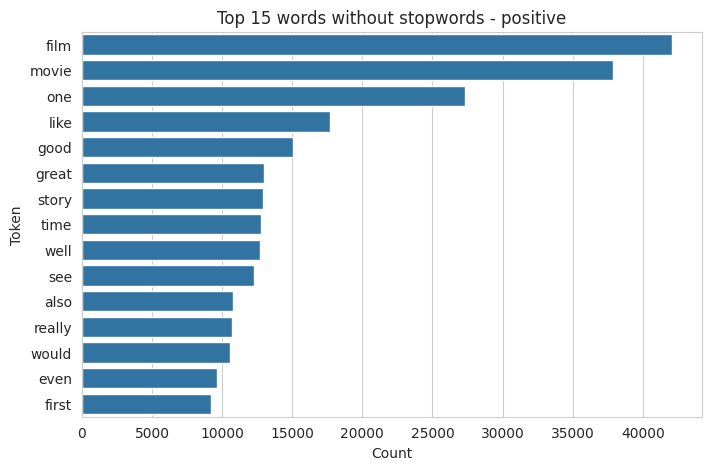


Top 15 szó - sentiment = negative


,token,count
0,movie,50119
1,film,37597
2,one,26283
3,like,22458
4,even,15254
5,good,14728
6,bad,14726
7,would,14007
8,time,12358
9,really,12355


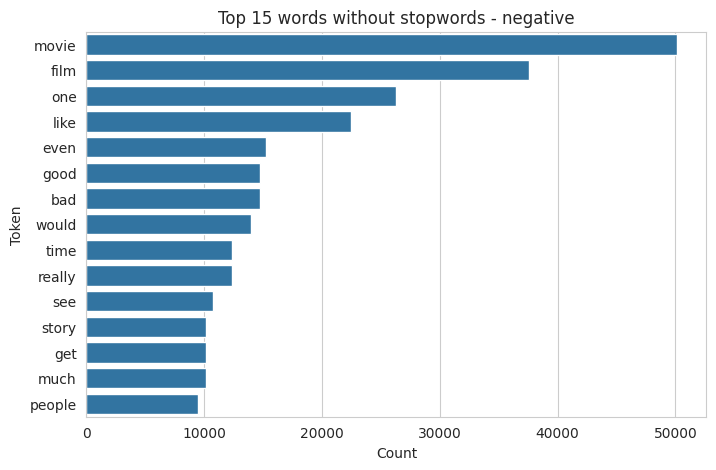


8. SZÉLSŐSÉGES ESETEK
Legrövidebb review-k:


,review,sentiment,char_len,word_count_raw,token_count_clean
27521,"Read the book, forget the movie!",negative,32,6,6
28920,Primary plot!Primary direction!Poor interpreta...,negative,51,4,6
13109,"More suspenseful, more subtle, much, much more...",negative,61,8,8
31072,"What a script, what a story, what a mess!",negative,41,9,9
40817,I hope this group of film-makers never re-unites.,negative,49,8,10


Leghosszabb review-k:


,review,sentiment,char_len,word_count_raw,token_count_clean
31481,Match 1: Tag Team Table Match Bubba Ray and Sp...,positive,13704,2470,2494
40521,There's a sign on The Lost Highway that says:<...,positive,12988,2278,2297
31240,"(Some spoilers included:)<br /><br />Although,...",positive,12930,2108,2151
31436,"Back in the mid/late 80s, an OAV anime by titl...",positive,12129,2125,2147
12647,Titanic directed by James Cameron presents a f...,positive,10321,1839,1841



9. GYORS EDA KONKLÚZIÓ
- Rekordok száma: 50000
- Duplikált review-k száma: 418
- Osztályeloszlás: {'positive': 0.5, 'negative': 0.5}
- Átlagos karakterszám: 1309.43
- Átlagos nyers szószám: 231.16
- Átlagos tisztított tokenszám: 234.19
- Átlagos stopword arány: 0.497

EDA kész. Az eda_df az alábbi új oszlopokat tartalmazza:
['char_len', 'word_count_raw', 'review_clean_basic', 'tokens_clean', 'token_count_clean', 'tokens_no_stop', 'stopword_count', 'non_stopword_count', 'stopword_ratio']


In [ ]:
# =========================================================
# EDA CELL – IMDb sentiment dataset
# Stabil Colab-verzió, NLTK punkt_tab nélkül is működik
# Feltételezi, hogy a df DataFrame már be van olvasva
# és léteznek ezek az oszlopok:
#   - review
#   - sentiment
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords

nltk.download('stopwords')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

eda_df = df.copy()

required_cols = ['review', 'sentiment']
missing_cols = [col for col in required_cols if col not in eda_df.columns]
if missing_cols:
    raise ValueError(f"Hiányzó oszlop(ok): {missing_cols}. Szükséges: {required_cols}")

print("="*70)
print("1. DATAFRAME ÁTTEKINTÉS")
print("="*70)
print(f"Alak (sor, oszlop): {eda_df.shape}")
print("\nOszlopok:")
print(eda_df.columns.tolist())

print("\nAdattípusok:")
print(eda_df.dtypes)

print("\nHiányzó értékek:")
print(eda_df.isna().sum())

print("\nDuplikált sorok száma:", eda_df.duplicated().sum())
print("Duplikált review-k száma:", eda_df['review'].duplicated().sum())

print("\nElső 3 sor:")
display(eda_df.head(3))

print("\n" + "="*70)
print("2. CÉLVÁLTOZÓ ELOSZLÁSA")
print("="*70)
sentiment_counts = eda_df['sentiment'].value_counts(dropna=False)
sentiment_ratio = eda_df['sentiment'].value_counts(normalize=True, dropna=False) * 100

summary_sent = pd.DataFrame({
    'count': sentiment_counts,
    'percent': sentiment_ratio.round(2)
})
display(summary_sent)

plt.figure(figsize=(7,4))
sns.countplot(data=eda_df, x='sentiment', order=eda_df['sentiment'].value_counts().index)
plt.title('Sentiment class distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

print("\n" + "="*70)
print("3. SZÖVEGHOSSZ JELLEMZŐK")
print("="*70)

eda_df['char_len'] = eda_df['review'].astype(str).apply(len)
eda_df['word_count_raw'] = eda_df['review'].astype(str).apply(lambda x: len(x.split()))

def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Regex-alapú tokenizálás: stabilabb EDA-hoz
def simple_tokenize(text):
    return re.findall(r'\b[a-zA-Z]+\b', text.lower())

eda_df['review_clean_basic'] = eda_df['review'].astype(str).apply(basic_clean)
eda_df['tokens_clean'] = eda_df['review_clean_basic'].apply(simple_tokenize)
eda_df['token_count_clean'] = eda_df['tokens_clean'].apply(len)

length_desc = eda_df[['char_len', 'word_count_raw', 'token_count_clean']].describe().T
display(length_desc)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(eda_df['char_len'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Character length distribution')
axes[0].set_xlabel('Characters')

sns.histplot(eda_df['word_count_raw'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Raw word count distribution')
axes[1].set_xlabel('Words')

sns.histplot(eda_df['token_count_clean'], bins=50, kde=True, ax=axes[2])
axes[2].set_title('Clean token count distribution')
axes[2].set_xlabel('Tokens')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("4. SZÖVEGHOSSZ SENTIMENT SZERINT")
print("="*70)

group_len = eda_df.groupby('sentiment')[['char_len', 'word_count_raw', 'token_count_clean']].agg(['mean', 'median', 'std', 'min', 'max'])
display(group_len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=eda_df, x='sentiment', y='word_count_raw', ax=axes[0])
axes[0].set_title('Raw word count by sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Word count')

sns.boxplot(data=eda_df, x='sentiment', y='token_count_clean', ax=axes[1])
axes[1].set_title('Clean token count by sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Token count')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("5. TOKEN ELEMZÉS")
print("="*70)

stop_words = set(stopwords.words('english'))

eda_df['tokens_no_stop'] = eda_df['tokens_clean'].apply(
    lambda toks: [t for t in toks if t not in stop_words]
)

eda_df['stopword_count'] = eda_df['tokens_clean'].apply(
    lambda toks: sum(1 for t in toks if t in stop_words)
)
eda_df['non_stopword_count'] = eda_df['tokens_no_stop'].apply(len)
eda_df['stopword_ratio'] = np.where(
    eda_df['token_count_clean'] > 0,
    eda_df['stopword_count'] / eda_df['token_count_clean'],
    0
)

token_stats = eda_df[['token_count_clean', 'stopword_count', 'non_stopword_count', 'stopword_ratio']].describe().T
display(token_stats)

plt.figure(figsize=(8,4))
sns.histplot(eda_df['stopword_ratio'], bins=40, kde=True)
plt.title('Stopword ratio distribution')
plt.xlabel('Stopword ratio')
plt.show()

print("\n" + "="*70)
print("6. LEGGYAKORIBB SZAVAK")
print("="*70)

all_tokens = [tok for doc in eda_df['tokens_clean'] for tok in doc]
all_tokens_no_stop = [tok for doc in eda_df['tokens_no_stop'] for tok in doc]

top_20_all = Counter(all_tokens).most_common(20)
top_20_no_stop = Counter(all_tokens_no_stop).most_common(20)

top_all_df = pd.DataFrame(top_20_all, columns=['token', 'count'])
top_no_stop_df = pd.DataFrame(top_20_no_stop, columns=['token', 'count'])

print("Top 20 token (stopwordökkel együtt):")
display(top_all_df)

print("Top 20 token (stopwordök nélkül):")
display(top_no_stop_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_all_df, x='count', y='token', ax=axes[0])
axes[0].set_title('Top 20 tokens (with stopwords)')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Token')

sns.barplot(data=top_no_stop_df, x='count', y='token', ax=axes[1])
axes[1].set_title('Top 20 tokens (without stopwords)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Token')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("7. LEGGYAKORIBB SZAVAK SENTIMENTENKÉNT")
print("="*70)

for label in eda_df['sentiment'].dropna().unique():
    subset_tokens = [tok for doc in eda_df.loc[eda_df['sentiment'] == label, 'tokens_no_stop'] for tok in doc]
    top_words = Counter(subset_tokens).most_common(15)
    top_df = pd.DataFrame(top_words, columns=['token', 'count'])

    print(f"\nTop 15 szó - sentiment = {label}")
    display(top_df)

    plt.figure(figsize=(8,5))
    sns.barplot(data=top_df, x='count', y='token')
    plt.title(f'Top 15 words without stopwords - {label}')
    plt.xlabel('Count')
    plt.ylabel('Token')
    plt.show()

print("\n" + "="*70)
print("8. SZÉLSŐSÉGES ESETEK")
print("="*70)

print("Legrövidebb review-k:")
display(
    eda_df[['review', 'sentiment', 'char_len', 'word_count_raw', 'token_count_clean']]
    .sort_values('token_count_clean', ascending=True)
    .head(5)
)

print("Leghosszabb review-k:")
display(
    eda_df[['review', 'sentiment', 'char_len', 'word_count_raw', 'token_count_clean']]
    .sort_values('token_count_clean', ascending=False)
    .head(5)
)

print("\n" + "="*70)
print("9. GYORS EDA KONKLÚZIÓ")
print("="*70)

n_rows = len(eda_df)
n_dup_reviews = eda_df['review'].duplicated().sum()
class_balance = eda_df['sentiment'].value_counts(normalize=True).round(3).to_dict()

print(f"- Rekordok száma: {n_rows}")
print(f"- Duplikált review-k száma: {n_dup_reviews}")
print(f"- Osztályeloszlás: {class_balance}")
print(f"- Átlagos karakterszám: {eda_df['char_len'].mean():.2f}")
print(f"- Átlagos nyers szószám: {eda_df['word_count_raw'].mean():.2f}")
print(f"- Átlagos tisztított tokenszám: {eda_df['token_count_clean'].mean():.2f}")
print(f"- Átlagos stopword arány: {eda_df['stopword_ratio'].mean():.3f}")

print("\nEDA kész. Az eda_df az alábbi új oszlopokat tartalmazza:")
print([
    'char_len',
    'word_count_raw',
    'review_clean_basic',
    'tokens_clean',
    'token_count_clean',
    'tokens_no_stop',
    'stopword_count',
    'non_stopword_count',
    'stopword_ratio'
])

##EDA - HU

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1. DATAFRAME ÁTTEKINTÉS
Alak (sor, oszlop): (50000, 2)

Oszlopok:
['review', 'sentiment']

Adattípusok:
review       object
sentiment    object
dtype: object

Hiányzó értékek:
review       0
sentiment    0
dtype: int64

Duplikált sorok száma: 418
Duplikált review-k száma: 418

Első 3 sor:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive



2. CÉLVÁLTOZÓ ELOSZLÁSA


,Gyakoriság,Százalék (%)
sentiment,,
positive,25000,50.0
negative,25000,50.0


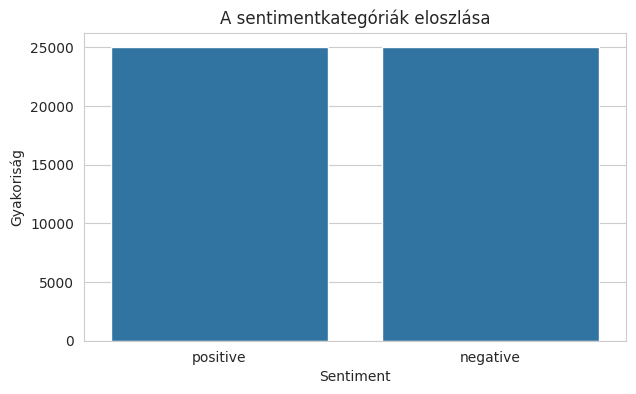


3. SZÖVEGHOSSZ JELLEMZŐK


,count,mean,std,min,25%,50%,75%,max
Karakterszám,50000.0,1309.43102,989.728014,32.0,699.0,970.0,1590.25,13704.0
Nyers szószám,50000.0,231.15694,171.343997,4.0,126.0,173.0,280.00,2470.0
Tisztított tokenszám,50000.0,234.18710,173.516096,6.0,128.0,176.0,284.00,2494.0


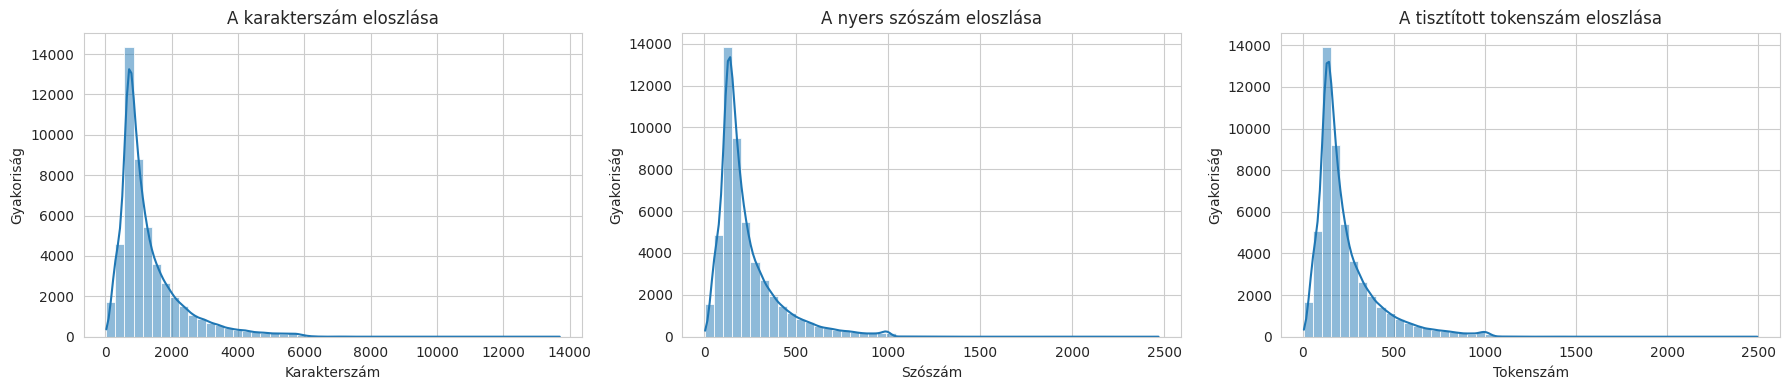


4. SZÖVEGHOSSZ SENTIMENT SZERINT


char_len                                word_count_raw         \
                 mean median          std min    max           mean median   
sentiment                                                                    
negative   1294.06436  973.0   945.892669  32   8969      229.46456  174.0   
positive   1324.79768  968.0  1031.492627  65  13704      232.84932  172.0   

                                token_count_clean                               
                  std min   max              mean median         std min   max  
sentiment                                                                       
negative   164.947795   4  1522         232.65904  176.5  167.213549   6  1539  
positive   177.497046  10  2470         235.71516  175.0  179.587957  10  2494

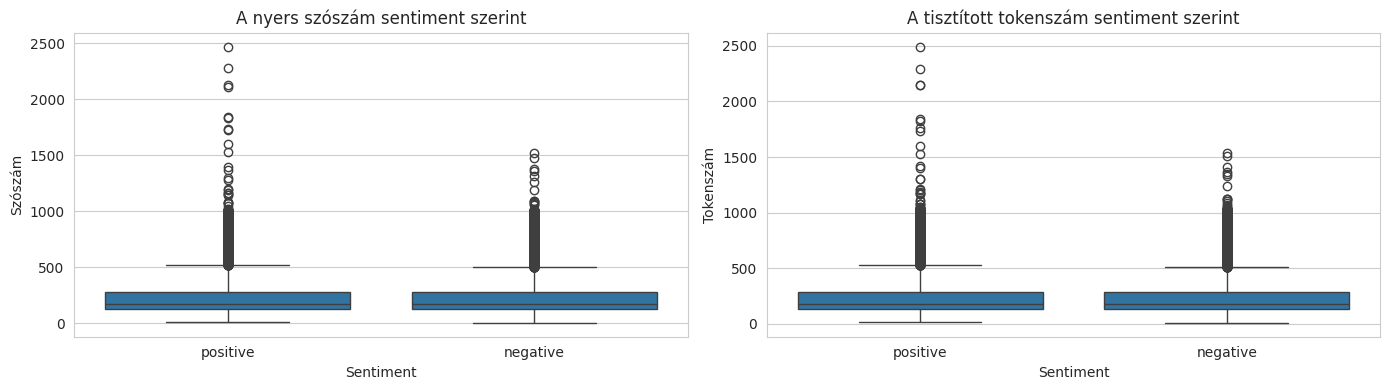


5. TOKEN ELEMZÉS


,count,mean,std,min,25%,50%,75%,max
Tisztított tokenszám,50000.0,234.187100,173.516096,6.0,128.000000,176.0,284.000000,2494.000000
Stopwordök száma,50000.0,116.033980,85.642658,0.0,64.000000,89.0,140.000000,1209.000000
Nem stopword tokenek száma,50000.0,118.153120,89.412558,3.0,63.000000,88.0,144.000000,1422.000000
Stopword arány,50000.0,0.496879,0.049196,0.0,0.466667,0.5,0.529412,0.692308


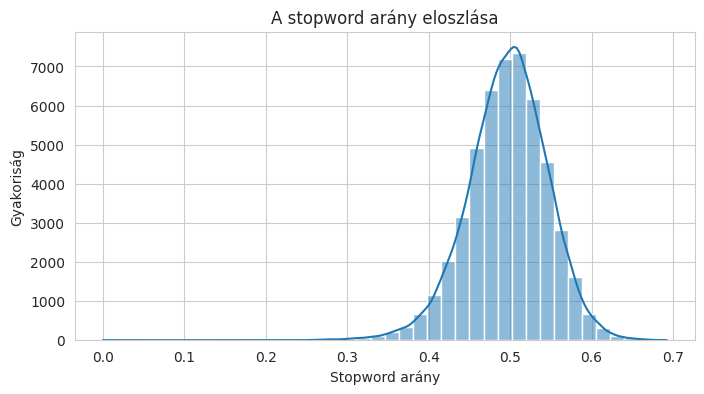


6. LEGGYAKORIBB SZAVAK
Top 20 token (stopwordökkel együtt):


,Token,Gyakoriság
0,the,668010
1,and,324446
2,a,323062
3,of,289416
4,to,268126
5,is,211093
6,it,190862
7,in,186788
8,i,175646
9,this,151002


Top 20 token (stopwordök nélkül):


,Token,Gyakoriság
0,movie,87973
1,film,79708
2,one,53603
3,like,40172
4,good,29753
5,time,25110
6,even,24872
7,would,24602
8,story,23121
9,really,23095


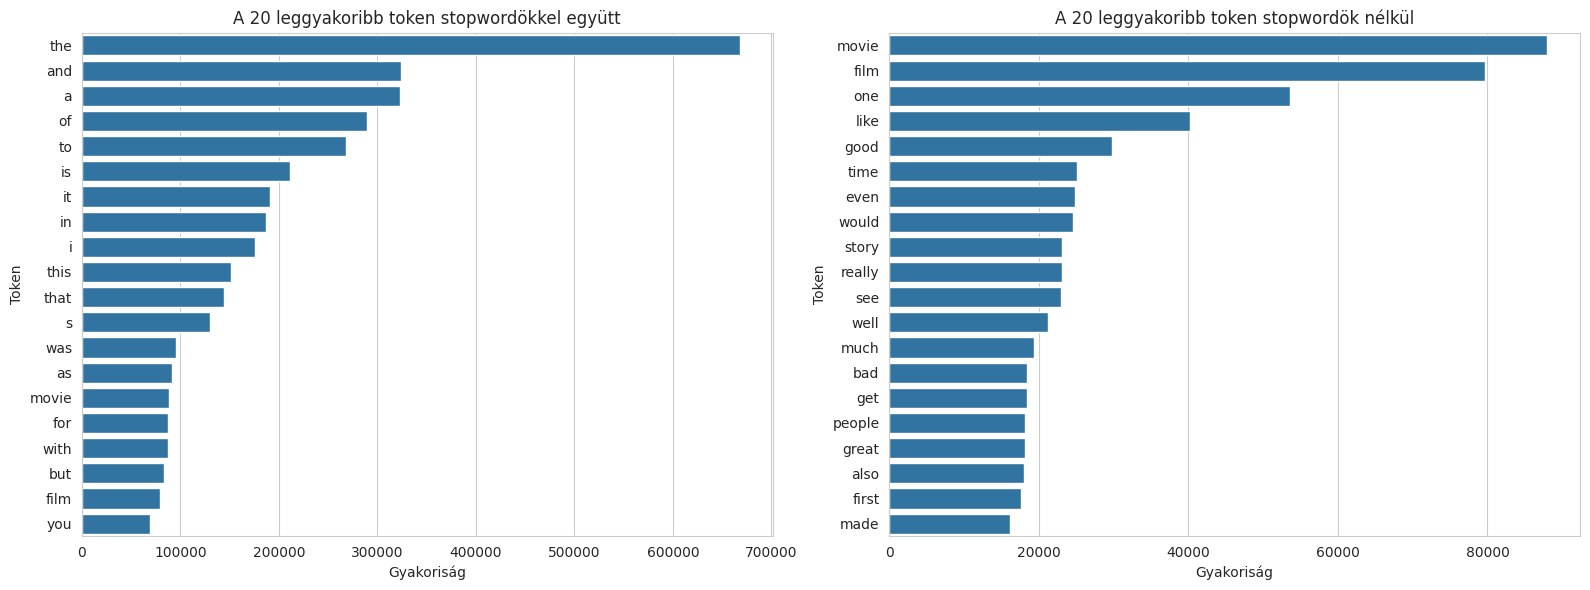


7. LEGGYAKORIBB SZAVAK SENTIMENTENKÉNT

Top 15 szó - sentiment = positive


,Token,Gyakoriság
0,film,42111
1,movie,37854
2,one,27320
3,like,17714
4,good,15025
5,great,12964
6,story,12935
7,time,12752
8,well,12729
9,see,12276


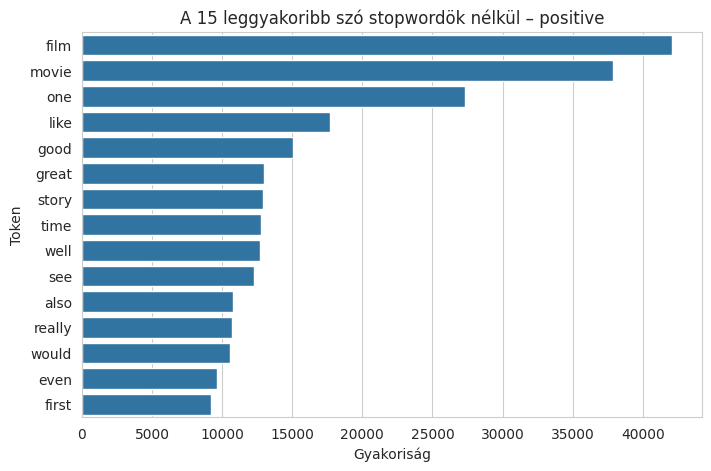


Top 15 szó - sentiment = negative


,Token,Gyakoriság
0,movie,50119
1,film,37597
2,one,26283
3,like,22458
4,even,15254
5,good,14728
6,bad,14726
7,would,14007
8,time,12358
9,really,12355


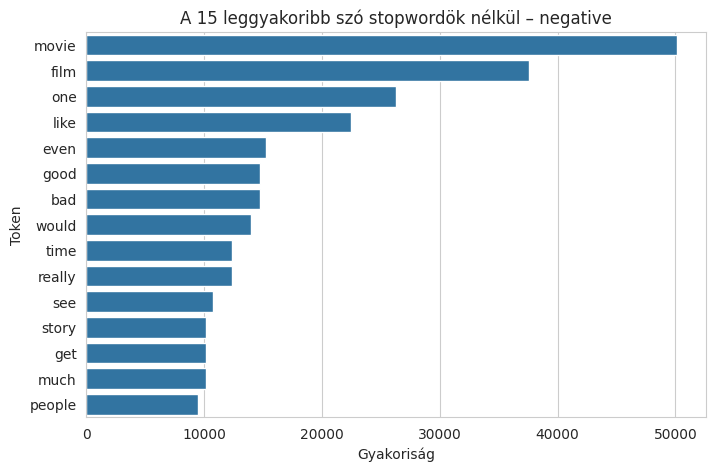


8. SZÉLSŐSÉGES ESETEK
Legrövidebb review-k:


,review,sentiment,char_len,word_count_raw,token_count_clean
27521,"Read the book, forget the movie!",negative,32,6,6
28920,Primary plot!Primary direction!Poor interpreta...,negative,51,4,6
13109,"More suspenseful, more subtle, much, much more...",negative,61,8,8
31072,"What a script, what a story, what a mess!",negative,41,9,9
40817,I hope this group of film-makers never re-unites.,negative,49,8,10


Leghosszabb review-k:


,review,sentiment,char_len,word_count_raw,token_count_clean
31481,Match 1: Tag Team Table Match Bubba Ray and Sp...,positive,13704,2470,2494
40521,There's a sign on The Lost Highway that says:<...,positive,12988,2278,2297
31240,"(Some spoilers included:)<br /><br />Although,...",positive,12930,2108,2151
31436,"Back in the mid/late 80s, an OAV anime by titl...",positive,12129,2125,2147
12647,Titanic directed by James Cameron presents a f...,positive,10321,1839,1841



9. GYORS EDA KONKLÚZIÓ
- Rekordok száma: 50000
- Duplikált review-k száma: 418
- Osztályeloszlás: {'positive': 0.5, 'negative': 0.5}
- Átlagos karakterszám: 1309.43
- Átlagos nyers szószám: 231.16
- Átlagos tisztított tokenszám: 234.19
- Átlagos stopword arány: 0.497

EDA kész. Az eda_df az alábbi új oszlopokat tartalmazza:
['char_len', 'word_count_raw', 'review_clean_basic', 'tokens_clean', 'token_count_clean', 'tokens_no_stop', 'stopword_count', 'non_stopword_count', 'stopword_ratio']


In [ ]:
# =========================================================
# EDA CELL – IMDb sentiment dataset
# Stabil Colab-verzió, NLTK punkt_tab nélkül is működik
# Feltételezi, hogy a df DataFrame már be van olvasva
# és léteznek ezek az oszlopok:
#   - review
#   - sentiment
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords

nltk.download('stopwords')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

eda_df = df.copy()

required_cols = ['review', 'sentiment']
missing_cols = [col for col in required_cols if col not in eda_df.columns]
if missing_cols:
    raise ValueError(f"Hiányzó oszlop(ok): {missing_cols}. Szükséges: {required_cols}")

print("="*70)
print("1. DATAFRAME ÁTTEKINTÉS")
print("="*70)
print(f"Alak (sor, oszlop): {eda_df.shape}")
print("\nOszlopok:")
print(eda_df.columns.tolist())

print("\nAdattípusok:")
print(eda_df.dtypes)

print("\nHiányzó értékek:")
print(eda_df.isna().sum())

print("\nDuplikált sorok száma:", eda_df.duplicated().sum())
print("Duplikált review-k száma:", eda_df['review'].duplicated().sum())

print("\nElső 3 sor:")
display(eda_df.head(3))

print("\n" + "="*70)
print("2. CÉLVÁLTOZÓ ELOSZLÁSA")
print("="*70)
sentiment_counts = eda_df['sentiment'].value_counts(dropna=False)
sentiment_ratio = eda_df['sentiment'].value_counts(normalize=True, dropna=False) * 100

summary_sent = pd.DataFrame({
    'Gyakoriság': sentiment_counts,
    'Százalék (%)': sentiment_ratio.round(2)
})
display(summary_sent)

plt.figure(figsize=(7,4))
sns.countplot(data=eda_df, x='sentiment', order=eda_df['sentiment'].value_counts().index)
plt.title('A sentimentkategóriák eloszlása')
plt.xlabel('Sentiment')
plt.ylabel('Gyakoriság')
plt.show()

print("\n" + "="*70)
print("3. SZÖVEGHOSSZ JELLEMZŐK")
print("="*70)

eda_df['char_len'] = eda_df['review'].astype(str).apply(len)
eda_df['word_count_raw'] = eda_df['review'].astype(str).apply(lambda x: len(x.split()))

def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Regex-alapú tokenizálás: stabilabb EDA-hoz
def simple_tokenize(text):
    return re.findall(r'\b[a-zA-Z]+\b', text.lower())

eda_df['review_clean_basic'] = eda_df['review'].astype(str).apply(basic_clean)
eda_df['tokens_clean'] = eda_df['review_clean_basic'].apply(simple_tokenize)
eda_df['token_count_clean'] = eda_df['tokens_clean'].apply(len)

length_desc = eda_df[['char_len', 'word_count_raw', 'token_count_clean']].describe().T
length_desc.index = ['Karakterszám', 'Nyers szószám', 'Tisztított tokenszám']
display(length_desc)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(eda_df['char_len'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('A karakterszám eloszlása')
axes[0].set_xlabel('Karakterszám')
axes[0].set_ylabel('Gyakoriság')

sns.histplot(eda_df['word_count_raw'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('A nyers szószám eloszlása')
axes[1].set_xlabel('Szószám')
axes[1].set_ylabel('Gyakoriság')

sns.histplot(eda_df['token_count_clean'], bins=50, kde=True, ax=axes[2])
axes[2].set_title('A tisztított tokenszám eloszlása')
axes[2].set_xlabel('Tokenszám')
axes[2].set_ylabel('Gyakoriság')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("4. SZÖVEGHOSSZ SENTIMENT SZERINT")
print("="*70)

group_len = eda_df.groupby('sentiment')[['char_len', 'word_count_raw', 'token_count_clean']].agg(['mean', 'median', 'std', 'min', 'max'])
display(group_len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=eda_df, x='sentiment', y='word_count_raw', ax=axes[0])
axes[0].set_title('A nyers szószám sentiment szerint')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Szószám')

sns.boxplot(data=eda_df, x='sentiment', y='token_count_clean', ax=axes[1])
axes[1].set_title('A tisztított tokenszám sentiment szerint')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Tokenszám')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("5. TOKEN ELEMZÉS")
print("="*70)

stop_words = set(stopwords.words('english'))

eda_df['tokens_no_stop'] = eda_df['tokens_clean'].apply(
    lambda toks: [t for t in toks if t not in stop_words]
)

eda_df['stopword_count'] = eda_df['tokens_clean'].apply(
    lambda toks: sum(1 for t in toks if t in stop_words)
)
eda_df['non_stopword_count'] = eda_df['tokens_no_stop'].apply(len)
eda_df['stopword_ratio'] = np.where(
    eda_df['token_count_clean'] > 0,
    eda_df['stopword_count'] / eda_df['token_count_clean'],
    0
)

token_stats = eda_df[['token_count_clean', 'stopword_count', 'non_stopword_count', 'stopword_ratio']].describe().T
token_stats.index = ['Tisztított tokenszám', 'Stopwordök száma', 'Nem stopword tokenek száma', 'Stopword arány']
display(token_stats)

plt.figure(figsize=(8,4))
sns.histplot(eda_df['stopword_ratio'], bins=40, kde=True)
plt.title('A stopword arány eloszlása')
plt.xlabel('Stopword arány')
plt.ylabel('Gyakoriság')
plt.show()

print("\n" + "="*70)
print("6. LEGGYAKORIBB SZAVAK")
print("="*70)

all_tokens = [tok for doc in eda_df['tokens_clean'] for tok in doc]
all_tokens_no_stop = [tok for doc in eda_df['tokens_no_stop'] for tok in doc]

top_20_all = Counter(all_tokens).most_common(20)
top_20_no_stop = Counter(all_tokens_no_stop).most_common(20)

top_all_df = pd.DataFrame(top_20_all, columns=['Token', 'Gyakoriság'])
top_no_stop_df = pd.DataFrame(top_20_no_stop, columns=['Token', 'Gyakoriság'])

print("Top 20 token (stopwordökkel együtt):")
display(top_all_df)

print("Top 20 token (stopwordök nélkül):")
display(top_no_stop_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_all_df, x='Gyakoriság', y='Token', ax=axes[0])
axes[0].set_title('A 20 leggyakoribb token stopwordökkel együtt')
axes[0].set_xlabel('Gyakoriság')
axes[0].set_ylabel('Token')

sns.barplot(data=top_no_stop_df, x='Gyakoriság', y='Token', ax=axes[1])
axes[1].set_title('A 20 leggyakoribb token stopwordök nélkül')
axes[1].set_xlabel('Gyakoriság')
axes[1].set_ylabel('Token')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("7. LEGGYAKORIBB SZAVAK SENTIMENTENKÉNT")
print("="*70)

for label in eda_df['sentiment'].dropna().unique():
    subset_tokens = [tok for doc in eda_df.loc[eda_df['sentiment'] == label, 'tokens_no_stop'] for tok in doc]
    top_words = Counter(subset_tokens).most_common(15)
    top_df = pd.DataFrame(top_words, columns=['Token', 'Gyakoriság'])

    print(f"\nTop 15 szó - sentiment = {label}")
    display(top_df)

    plt.figure(figsize=(8,5))
    sns.barplot(data=top_df, x='Gyakoriság', y='Token')
    plt.title(f'A 15 leggyakoribb szó stopwordök nélkül – {label}')
    plt.xlabel('Gyakoriság')
    plt.ylabel('Token')
    plt.show()

print("\n" + "="*70)
print("8. SZÉLSŐSÉGES ESETEK")
print("="*70)

print("Legrövidebb review-k:")
display(
    eda_df[['review', 'sentiment', 'char_len', 'word_count_raw', 'token_count_clean']]
    .sort_values('token_count_clean', ascending=True)
    .head(5)
)

print("Leghosszabb review-k:")
display(
    eda_df[['review', 'sentiment', 'char_len', 'word_count_raw', 'token_count_clean']]
    .sort_values('token_count_clean', ascending=False)
    .head(5)
)

print("\n" + "="*70)
print("9. GYORS EDA KONKLÚZIÓ")
print("="*70)

n_rows = len(eda_df)
n_dup_reviews = eda_df['review'].duplicated().sum()
class_balance = eda_df['sentiment'].value_counts(normalize=True).round(3).to_dict()

print(f"- Rekordok száma: {n_rows}")
print(f"- Duplikált review-k száma: {n_dup_reviews}")
print(f"- Osztályeloszlás: {class_balance}")
print(f"- Átlagos karakterszám: {eda_df['char_len'].mean():.2f}")
print(f"- Átlagos nyers szószám: {eda_df['word_count_raw'].mean():.2f}")
print(f"- Átlagos tisztított tokenszám: {eda_df['token_count_clean'].mean():.2f}")
print(f"- Átlagos stopword arány: {eda_df['stopword_ratio'].mean():.3f}")

print("\nEDA kész. Az eda_df az alábbi új oszlopokat tartalmazza:")
print([
    'char_len',
    'word_count_raw',
    'review_clean_basic',
    'tokens_clean',
    'token_count_clean',
    'tokens_no_stop',
    'stopword_count',
    'non_stopword_count',
    'stopword_ratio'
])

##Textblob

In [ ]:
#display(df)

In [ ]:
display(movie_reviews)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [ ]:
display(df['sentiment'].value_counts())

print('Duplicated: ', df.duplicated().sum())
print('Null:', df.isnull().sum())

,count
sentiment,
positive,25000
negative,25000


Duplicated:  418
Null: review       0
sentiment    0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
df['review'][10]

'Phil the Alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlines.<br /><br />At first it was very odd and pretty funny but as the movie progressed I didn\'t find the jokes or oddness funny anymore.<br /><br />Its a low budget film (thats never a problem in itself), there were some pretty interesting characters, but eventually I just lost interest.<br /><br />I imagine this film would appeal to a stoner who is currently partaking.<br /><br />For something similar but better try "Brother from another planet"'

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def clean_and_token(text):
    text = text.lower()    # Convert to lowercase
    text = re.sub(r'<.*?>',' ',text)  # Remove HTML tags
    text = re.sub(r'[^a-z\s]','',text)  # Remove special characters & numbers
    tokens = word_tokenize(text)  # Tokenize into words
    tokens = [word for word in tokens if word not in stop_words and len(word)>2] # Remove stopwords & short words
    tokens = [word for word in tokens if not re.search(r'(.)\1{2,}',word)]  # Remove words with 3+ repeated letters
    return tokens


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df['tokens'] = df['review'].apply(clean_and_token)

In [ ]:
from textblob import TextBlob

def get_sentiment_polarity(review):
    return TextBlob(review).sentiment.polarity

df['textblob'] = df['review'].astype(str).apply(get_sentiment_polarity)
df['textblob_posneg']=df['textblob'].apply(lambda x: 'positive' if x>0 else 'negative')


In [ ]:
df

,review,sentiment,tokens,textblob,textblob_posneg
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, episode,...",0.023433,positive
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, filming, techn...",0.109722,positive
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",0.354008,positive
3,Basically there's a family where a little boy ...,negative,"[basically, theres, family, little, boy, jake,...",-0.057813,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, matteis, love, time, money, visually,...",0.217952,positive
...,...,...,...,...,...
49577,I thought this movie did a down right good job...,positive,"[thought, movie, right, good, job, wasnt, crea...",0.394425,positive
49578,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"[bad, plot, bad, dialogue, bad, acting, idioti...",-0.276190,negative
49579,I am a Catholic taught in parochial elementary...,negative,"[catholic, taught, parochial, elementary, scho...",0.056984,positive
49580,I'm going to have to disagree with the previou...,negative,"[going, disagree, previous, comment, side, mal...",-0.048663,negative




Számoljuk ki és jelenítsük meg confusion mátrix segítségével a Textblob eredményét az eredeti értékeléshez képest.


<Axes: >

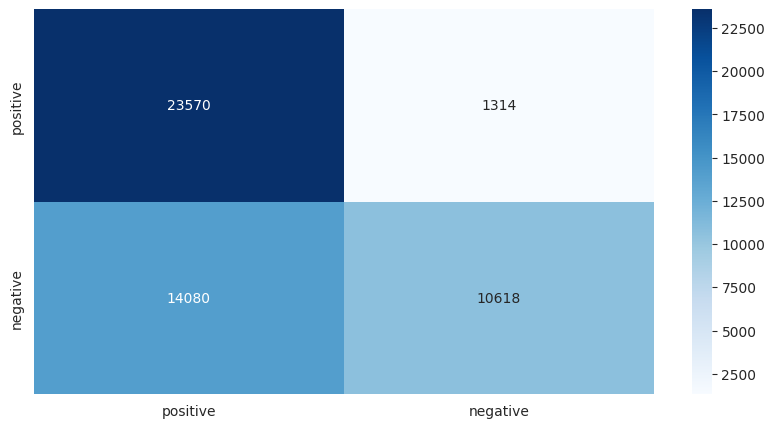

In [ ]:
conf_matrix_pattern = confusion_matrix(df['sentiment'],df['textblob_posneg'], labels=['positive', 'negative'])
sns.heatmap(conf_matrix_pattern, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])


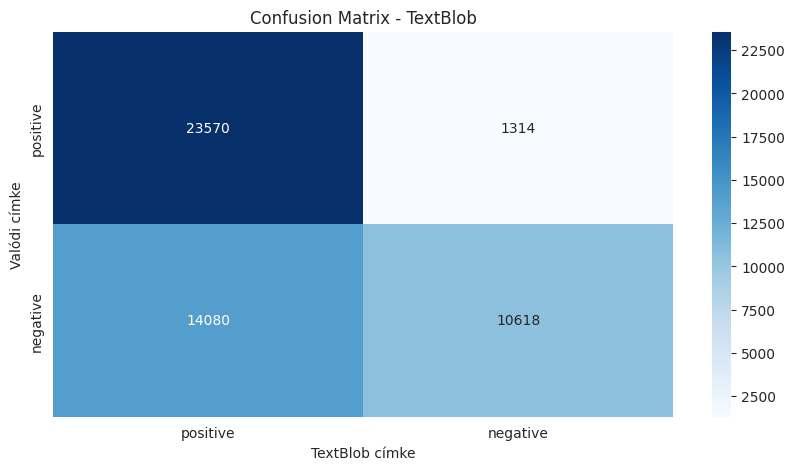

In [ ]:
conf_matrix_pattern = confusion_matrix(df['sentiment'],df['textblob_posneg'], labels=['positive', 'negative'])
sns.heatmap(conf_matrix_pattern, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.title("Confusion Matrix - TextBlob")
plt.xlabel("TextBlob címke")
plt.ylabel("Valódi címke")
plt.show()

Kiszámítható az eredeti szentiment címkék és a generált címkék egyezésének az aránya is az alábbi módon.

In [ ]:
similarity_patt = (df['textblob_posneg'] == df['sentiment']).mean()
print(f"Egyezés aránya: {similarity_patt:.2%}")


Egyezés aránya: 68.95%


In [ ]:
TP = conf_matrix_pattern[0, 0]  # True Positives
FN = conf_matrix_pattern[0, 1]  # False Negatives
FP = conf_matrix_pattern[1, 0]  # False Positives
TN = conf_matrix_pattern[1, 1]  # True Negatives

# Compute evaluation metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)  # Correctly classified samples

# Print results
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.69


Nézzük meg, hogyan változik apontosság ha csak a tokenet veszi figyelembe az algoritmus, nem pedig a majdnem nyers szöveget.

<Axes: >

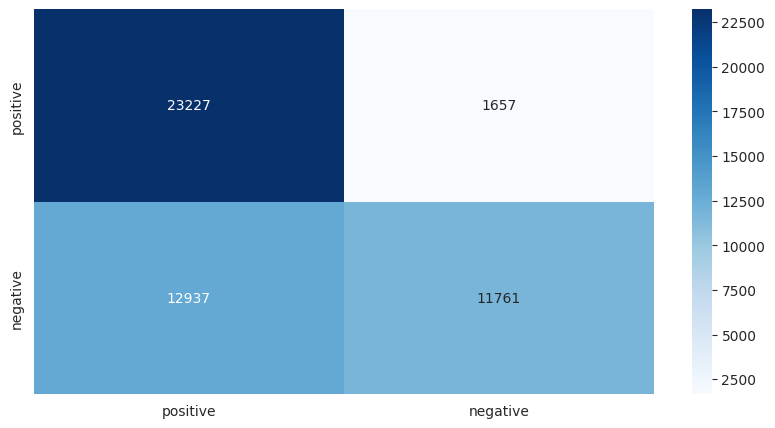

In [ ]:
df['textblob_token'] = df['tokens'].astype(str).apply(get_sentiment_polarity)
df['textblob_token_posneg']=df['textblob_token'].apply(lambda x: 'positive' if x>0 else 'negative')
conf_matrix_pattern = confusion_matrix(df['sentiment'],df['textblob_token_posneg'], labels=['positive', 'negative'])
sns.heatmap(conf_matrix_pattern, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])

##VADER

A VADER-t kifejezetten rövidebb, hétköznapi szövegek – például közösségi média-posztok, kommentek vagy filmkritikák – értelmezésére fejlesztették ki.

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader_sentiment = SentimentIntensityAnalyzer()
def vader_score(text):
    score = vader_sentiment.polarity_scores(text)
    return score['compound']

df['vader_token'] = df['tokens'].astype(str).apply(vader_score)
df['vader_token_posneg']=df['vader_token'].apply(lambda x: 'positive' if x>0 else 'negative')



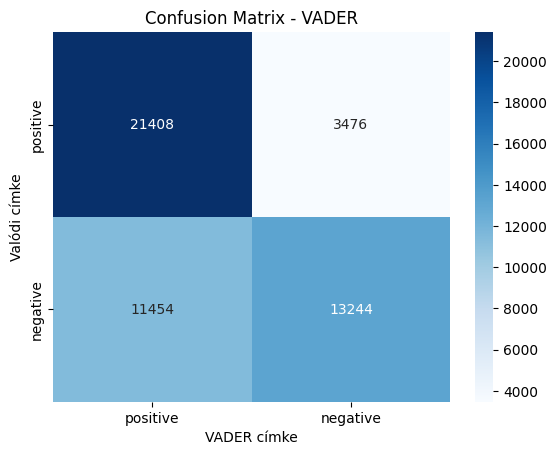

Hasonlóság mértéke: 69.89%
Accuracy: 0.70


In [ ]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1) tokens oszlop létrehozása, ha nincs
if "tokens" not in df.columns:
    def simple_tokens(text):
        text = str(text).lower()
        text = re.sub(r"[^a-z0-9\s']", " ", text)   # alap tisztítás (angol IMDb-hez ok)
        return text.split()
    df["tokens"] = df["review"].apply(simple_tokens)

# 2) sentiment egységesítése positive/negative-ra (IMDb pos/neg -> positive/negative)
df["sentiment_std"] = df["sentiment"].astype(str).str.lower().replace({
    "pos": "positive",
    "neg": "negative"
})

# 3) VADER
vader_sentiment = SentimentIntensityAnalyzer()

def vader_score(text):
    score = vader_sentiment.polarity_scores(str(text))
    return score["compound"]

# tokens list -> sztring (VADER-hez)
df["vader_token"] = df["tokens"].apply(lambda toks: " ".join(toks) if isinstance(toks, list) else str(toks)).apply(vader_score)
df["vader_token_posneg"] = df["vader_token"].apply(lambda x: "positive" if x > 0 else "negative")

# 4) Confusion matrix + ábra
conf_matrix_pattern = confusion_matrix(
    df["sentiment_std"],
    df["vader_token_posneg"],
    labels=["positive", "negative"]
)

sns.heatmap(
    conf_matrix_pattern,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["positive", "negative"],
    yticklabels=["positive", "negative"]
)
plt.title("Confusion Matrix - VADER")
plt.xlabel("VADER címke")
plt.ylabel("Valódi címke")
plt.show()

# 5) Hasonlóság (egyezési arány)
similarity_patt = (df["vader_token_posneg"] == df["sentiment_std"]).mean()
print(f"Hasonlóság mértéke: {similarity_patt:.2%}")

# 6) TP/FN/FP/TN + Accuracy
TP = conf_matrix_pattern[0, 0]  # True Positives
FN = conf_matrix_pattern[0, 1]  # False Negatives
FP = conf_matrix_pattern[1, 0]  # False Positives
TN = conf_matrix_pattern[1, 1]  # True Negatives

accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f"Accuracy: {accuracy:.2f}")

In [ ]:
from sklearn.metrics import accuracy_score

# ha az IMDb sentiment pos/neg formában van, egységesítsük
true_labels = df["sentiment"].astype(str).str.lower().replace({
    "pos": "positive",
    "neg": "negative"
})

# TextBlob accuracy
textblob_accuracy = accuracy_score(true_labels, df["textblob_posneg"])

# VADER accuracy
vader_accuracy = accuracy_score(true_labels, df["vader_token_posneg"])

print(f"TextBlob Accuracy: {textblob_accuracy:.3f}")
print(f"VADER Accuracy: {vader_accuracy:.3f}")

TextBlob Accuracy: 0.690
VADER Accuracy: 0.699


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# IMDb sentiment egységesítése
true_labels = df["sentiment"].astype(str).str.lower().replace({
    "pos": "positive",
    "neg": "negative"
})

# ----- TextBlob -----
tb_pred = df["textblob_posneg"]

tb_accuracy = accuracy_score(true_labels, tb_pred)
tb_precision = precision_score(true_labels, tb_pred, pos_label="positive")
tb_recall = recall_score(true_labels, tb_pred, pos_label="positive")
tb_f1 = f1_score(true_labels, tb_pred, pos_label="positive")

# ----- VADER -----
vd_pred = df["vader_token_posneg"]

vd_accuracy = accuracy_score(true_labels, vd_pred)
vd_precision = precision_score(true_labels, vd_pred, pos_label="positive")
vd_recall = recall_score(true_labels, vd_pred, pos_label="positive")
vd_f1 = f1_score(true_labels, vd_pred, pos_label="positive")

print("TEXTBLOB METRICS")
print(f"Accuracy : {tb_accuracy:.3f}")
print(f"Precision: {tb_precision:.3f}")
print(f"Recall   : {tb_recall:.3f}")
print(f"F1-score : {tb_f1:.3f}")

print("\nVADER METRICS")
print(f"Accuracy : {vd_accuracy:.3f}")
print(f"Precision: {vd_precision:.3f}")
print(f"Recall   : {vd_recall:.3f}")
print(f"F1-score : {vd_f1:.3f}")

TEXTBLOB METRICS
Accuracy : 0.690
Precision: 0.626
Recall   : 0.947
F1-score : 0.754

VADER METRICS
Accuracy : 0.699
Precision: 0.651
Recall   : 0.860
F1-score : 0.741


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# IMDb címkék egységesítése
true_labels = df["sentiment"].astype(str).str.lower().replace({
    "pos": "positive",
    "neg": "negative"
})

# Predikciók
textblob_pred = df["textblob_posneg"]
vader_pred = df["vader_token_posneg"]

# Metrikák számítása
metrics = {
    "Model": ["TextBlob", "VADER"],
    "Accuracy": [
        accuracy_score(true_labels, textblob_pred),
        accuracy_score(true_labels, vader_pred)
    ],
    "Precision": [
        precision_score(true_labels, textblob_pred, pos_label="positive"),
        precision_score(true_labels, vader_pred, pos_label="positive")
    ],
    "Recall": [
        recall_score(true_labels, textblob_pred, pos_label="positive"),
        recall_score(true_labels, vader_pred, pos_label="positive")
    ],
    "F1-score": [
        f1_score(true_labels, textblob_pred, pos_label="positive"),
        f1_score(true_labels, vader_pred, pos_label="positive")
    ]
}

metrics_df = pd.DataFrame(metrics)

# kerekítés publikációhoz
metrics_df.iloc[:,1:] = metrics_df.iloc[:,1:].round(3)

display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-score
0,TextBlob,0.690,0.626,0.947,0.754
1,VADER,0.699,0.651,0.860,0.741


# Elvégzendő elemzések -  NEURÁLIS Háló


1.  **IMDb filmkritikák adatkészletének (50 000 kritika)** betöltése
2.   **Adatok előfeldolgozása** speciális karakterek, számok stb. eltávolításával a felhasználói értékelésekből + a pozitív és negatív **érzékcímkék** konvertálása 1-es, illetve 0-s számmá
3.  **A GloVe szóbeágyazás Importálása** a beágyazási szótár létrehozásához + Használd ezt a korpuszunkhoz tartozó beágyazási mátrix létrehozásához
4. Modelltanítás **Keras mélytanulással** különálló: **egyszerű neurális hálózat, CNN és ​​LSTM modellek** esetén, valamint a modell teljesítményének és eredményeinek elemzése
4. **jóslatokat elvégzése valódi IMDb filmkritikák alapján** (opcionálisan elvégezhetó feladat)



#Neurális háló alapú szentiment analízis

## A környezet beállítása

In [5]:
#Google Drive csatolása

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Eszköztár mappa beállítása munkakönyvtárként


%cd /content/drive/My Drive/Privat/Study/PE/SZD/IMDb_Sentiment
! ls

In [7]:
# # Alapvető könyvtárak és függvények importálása


# import pandas as pd
# import numpy as np
# import re
# import nltk
# from nltk.corpus import stopwords
# from numpy import array

# from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from keras.models import Sequential
# from keras.layers.core import Activation, Dropout, Dense
# from keras.layers import Flatten, GlobalMaxPooling1D, Embedding, Conv1D, LSTM
# from sklearn.model_selection import train_test_split

In [9]:
# --- Core libs ellenőrzés
import pandas as pd
import numpy as np
import re

# --- NLTK
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

# --- TensorFlow / Keras (Colab-kompatibilis)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense, Flatten, GlobalMaxPooling1D, Embedding, Conv1D, LSTM

# --- Sklearn
from sklearn.model_selection import train_test_split

print("OK ✅")
print("TensorFlow:", tf.__version__)
print("Stopwords sample:", list(stopwords.words("english")[:10]))

OK ✅
TensorFlow: 2.19.0
Stopwords sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [10]:
#df = pd.read_csv("hf://datasets/Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup/archive.zip") #GJ
movie_reviews = pd.read_csv("IMDB_Dataset.csv") #KR

## Adatkészlet betöltése

In [11]:
# # IMDb filmkritikák adatkészletének betöltése/importálása


movie_reviews = pd.read_csv("IMDB_Dataset.csv")

# dataset source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


In [ ]:
# Adatkészlet-feltárás

movie_reviews.shape

(50000, 2)

In [12]:
movie_reviews.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
# Hiányzó értékek ellenőrzése

movie_reviews.isnull().values.any()

np.False_

<Axes: xlabel='sentiment', ylabel='count'>

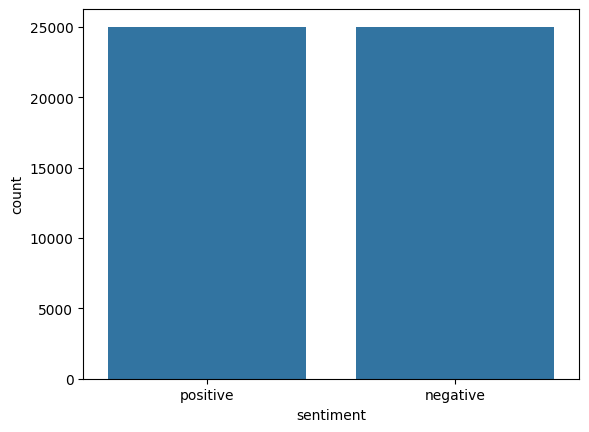

In [14]:
# A a pozitív/negatív érzések eloszlásának átteklintése az adathalmazban!
import seaborn as sns
sns.countplot(x='sentiment', data=movie_reviews)

/tmp/ipykernel_1002/1303936707.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=movie_reviews, palette=palette)


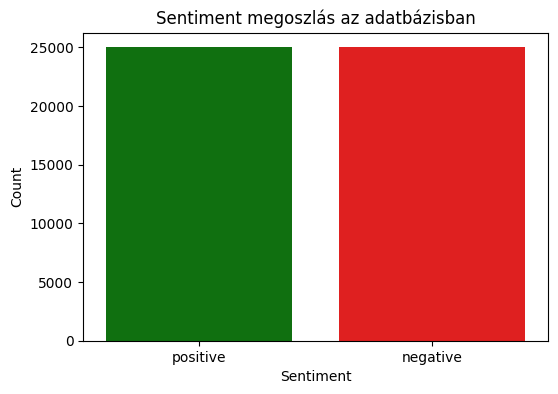

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fix színmapping
palette = {
    'positive': 'green',
    'negative': 'red'
}

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=movie_reviews, palette=palette)

plt.title("Sentiment megoszlás az adatbázisban")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## Adat előfeldologozás

In [15]:
movie_reviews["review"][5]

# Mivel a korpusz írásjeleket, zárójeleket, HTML-címkéket és számokat tartalmaz
# A szöveg előfeldolgozását a következő szakaszban fogjuk végezni

'Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it\'s not preachy or boring. It just never gets old, despite my having seen it some 15 or more times in the last 25 years. Paul Lukas\' performance brings tears to my eyes, and Bette Davis, in one of her very few truly sympathetic roles, is a delight. The kids are, as grandma says, more like "dressed-up midgets" than children, but that only makes them more fun to watch. And the mother\'s slow awakening to what\'s happening in the world and under her own roof is believable and startling. If I had a dozen thumbs, they\'d all be "up" for this movie.'

In [18]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    '''HTML-címkék eltávolítása: a nyitó és záró <> karakterek között lévő bármit üres szóközre cserél kisbetűvel'''

    return TAG_RE.sub('', text)

In [19]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
def preprocess_text(sen):
    ''''''

    sentence = sen.lower()

    # HTML-címkék eltávolítása
    sentence = remove_tags(sentence)

    # Írásjelek és a számok eltávolítása
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    #Egyedi karakterek eltávolítása
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)  # When we remove apostrophe from the word "Mark's", the apostrophe is replaced by an empty space. Hence, we are left with single character "s" that we are removing here.

    # Remove többszörös spaces-e. eltávolítása
    sentence = re.sub(r'\s+', ' ', sentence)  # Next, we remove all the single characters and replace it by a space which creates multiple spaces in our text. Finally, we remove the multiple spaces from our text as well.

    # Stopword-ök eltávolítása
    pattern = re.compile(r'\b(' + r'|'.join(stopwords.words('english')) + r')\b\s*')
    sentence = pattern.sub('', sentence)

    return sentence

In [21]:
# A preprocessing_text függvény meghívása a movie_reviews függvényen

X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

In [22]:
# Minta letisztított filmkritika

X[5]

# Mivel a szóbeágyazásokat fogjuk használni, a stemming/lemmatization itt nem kerül előfeldolgozási lépésként végrehajtásra.

'probably time favorite movie story selflessness sacrifice dedication noble cause preachy boring never gets old despite seen times last years paul lukas performance brings tears eyes bette davis one truly sympathetic roles delight kids grandma says like dressed midgets children makes fun watch mother slow awakening happening world roof believable startling dozen thumbs movie '

In [23]:
# Érzelmi címkék konvertálása 0-ra és 1-re

y = movie_reviews['sentiment']

y = np.array(list(map(lambda x: 1 if x=="positive" else 0, y)))

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# A train készletet a mélytanulási modelljeink betanítására fogjuk használni
# míg a tesztkészletet a modellünk teljesítményének értékelésére fogjuk használni

## Beágyazási (embedding) réteg előkészítése

Most megírjuk a beágyazási rétegünk szkriptjét. A beágyazási réteg a szöveges adatainkat numerikus formába alakítja. Ezután a Keras mélytanulási modelljeinek első rétegeként használjuk

In [25]:
# A beágyazási réteg numerikus formátumú szavakat vár
# A keras.preprocessing.text könyvtár Tokenizer függvényének használata
# A fit_on_text metódus betanítja a tokenizert
# A texts_to_sequences metódus a mondatokat numerikus formára konvertálja

word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)

X_train = word_tokenizer.texts_to_sequences(X_train)
X_test = word_tokenizer.texts_to_sequences(X_test)

In [26]:
# 1 hozzáadása az olyan szavak tárolási dimenzióinak tárolására, amelyekhez nincsenek előre betanított szóbeágyazások
vocab_length = len(word_tokenizer.word_index) + 1
vocab_length

92394

In [27]:
# Az összes értékelés kitöltése fix hosszúságúra, 100-ra

maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

In [28]:
# GloVe szóbeágyzás betöltése és a beagyazási szótár létrehozása

from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [29]:
# 100 oszlopból álló beágyazási mátrix létrehozása
# 100 dimenziós GloVe szóbeágyazások a korpuszunkban található összes szóhoz

embedding_matrix = zeros((vocab_length, 100))
for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [30]:
embedding_matrix.shape

(92394, 100)

# Model Tanítás:

## Simple Neural Network

In [31]:
# Egyszerű neurális hálózat

snn_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)

snn_model.add(embedding_layer)

snn_model.add(Flatten())
snn_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
# Model compiling

snn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

print(snn_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [33]:
# SNN model tanítása

snn_model_history = snn_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.7143 - loss: 0.5569 - val_acc: 0.7641 - val_loss: 0.4992
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - acc: 0.7955 - loss: 0.4491 - val_acc: 0.7588 - val_loss: 0.5077
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.8166 - loss: 0.4116 - val_acc: 0.7620 - val_loss: 0.5021
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.8282 - loss: 0.3905 - val_acc: 0.7626 - val_loss: 0.5065
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.8373 - loss: 0.3735 - val_acc: 0.7598 - val_loss: 0.5186
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8424 - loss: 0.3632 - val_acc: 0.7563 - val_loss: 0.5368


In [34]:
# Predikció a Teszt halmazon

score = snn_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7455 - loss: 0.5615


In [35]:
# Model teljesítmény

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.5614590048789978
Test Accuracy: 0.7455000281333923


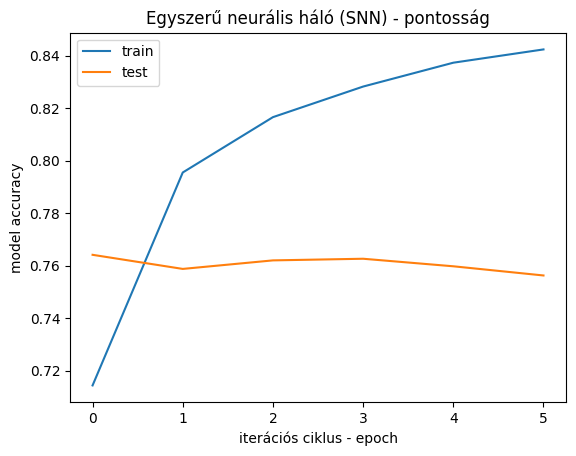

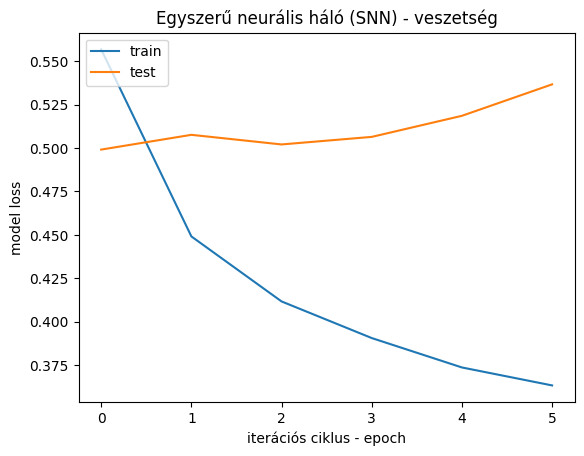

In [37]:
# Model teljesítmény Ábrázolása - SNN

import matplotlib.pyplot as plt

plt.plot(snn_model_history.history['acc'])
plt.plot(snn_model_history.history['val_acc'])

plt.title('Egyszerű neurális háló (SNN) - pontosság')
plt.ylabel('model accuracy')
plt.xlabel('iterációs ciklus - epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(snn_model_history.history['loss'])
plt.plot(snn_model_history.history['val_loss'])

plt.title('Egyszerű neurális háló (SNN) - veszetség')
plt.ylabel('model loss')
plt.xlabel('iterációs ciklus - epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

##Konvolúciós neurálsi háló - CNN

In [38]:
from keras.layers import Conv1D

In [39]:
# CNN modell tanítása

cnn_model = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
cnn_model.add(embedding_layer)

cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(GlobalMaxPooling1D())
cnn_model.add(Dense(1, activation='sigmoid'))

In [40]:
# Model compiling

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(cnn_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [41]:
# CNN modell tanítása

cnn_model_history = cnn_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - acc: 0.7712 - loss: 0.4731 - val_acc: 0.8316 - val_loss: 0.3800
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - acc: 0.8562 - loss: 0.3391 - val_acc: 0.8204 - val_loss: 0.3932
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - acc: 0.8836 - loss: 0.2881 - val_acc: 0.8393 - val_loss: 0.3566
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - acc: 0.9079 - loss: 0.2441 - val_acc: 0.8363 - val_loss: 0.3638
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step - acc: 0.9285 - loss: 0.2058 - val_acc: 0.8512 - val_loss: 0.3373
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - acc: 0.9504 - loss: 0.1673 - val_acc: 0.8537 - val_loss: 0.3381


In [42]:
# Predikciók a Teszt halmazon

score = cnn_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8500 - loss: 0.3406


In [43]:
# CNN model teljesítmény

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.34057098627090454
Test Accuracy: 0.8500000238418579


In [44]:
# Train accuracy (utolsó epoch)
train_acc = cnn_model_history.history.get('accuracy',
               cnn_model_history.history.get('acc'))[-1]

# Test accuracy
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)

# Difference
diff = train_acc - test_acc

print("Train pontosság (CNN) :", train_acc)
print("Test pontosság  (CNN) :", test_acc)
print("Különbség       (CNN) :", diff)

Train pontosság (CNN) : 0.9504374861717224
Test pontosság  (CNN) : 0.8500000238418579
Különbség       (CNN) : 0.1004374623298645


In [45]:
# --- SNN (Simple Neural Net) ---
snn_train_acc = snn_model_history.history.get('accuracy', snn_model_history.history.get('acc'))[-1]
_, snn_test_acc = snn_model.evaluate(X_test, y_test, verbose=0)
snn_diff = snn_train_acc - snn_test_acc

# --- CNN (Convolutional Neural Net) ---
cnn_train_acc = cnn_model_history.history.get('accuracy', cnn_model_history.history.get('acc'))[-1]
_, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
cnn_diff = cnn_train_acc - cnn_test_acc

print("SNN  | Train Accuracy :", snn_train_acc)
print("SNN  | Test  Accuracy :", snn_test_acc)
print("SNN  | Difference     :", snn_diff)
print("-" * 35)
print("CNN  | Train Accuracy :", cnn_train_acc)
print("CNN  | Test  Accuracy :", cnn_test_acc)
print("CNN  | Difference     :", cnn_diff)

SNN  | Train Accuracy : 0.8424062728881836
SNN  | Test  Accuracy : 0.7455000281333923
SNN  | Difference     : 0.09690624475479126
-----------------------------------
CNN  | Train Accuracy : 0.9504374861717224
CNN  | Test  Accuracy : 0.8500000238418579
CNN  | Difference     : 0.1004374623298645


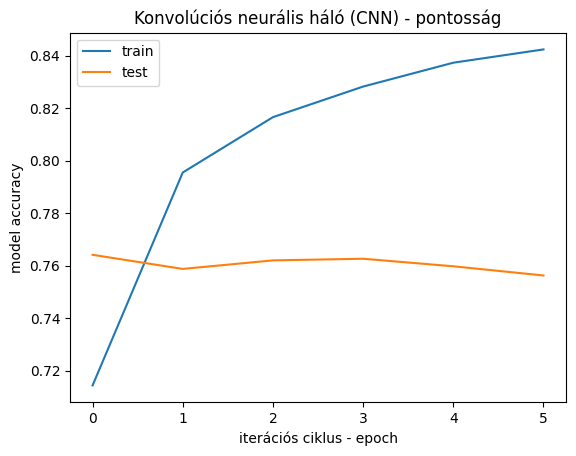

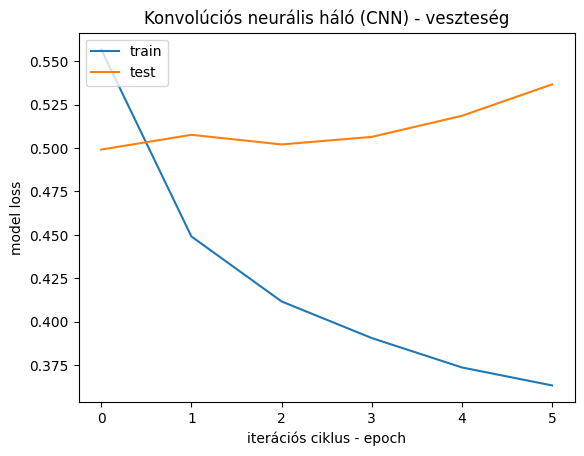

In [46]:
# Model Performance Charts- Konvolúciós neurális háló


import matplotlib.pyplot as plt

plt.plot(snn_model_history.history['acc'])
plt.plot(snn_model_history.history['val_acc'])

plt.title('Konvolúciós neurális háló (CNN) - pontosság')
plt.ylabel('model accuracy')
plt.xlabel('iterációs ciklus - epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(snn_model_history.history['loss'])
plt.plot(snn_model_history.history['val_loss'])

plt.title('Konvolúciós neurális háló (CNN) - veszteség')
plt.ylabel('model loss')
plt.xlabel('iterációs ciklus - epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

## Recurrent Neural Network (LSTM)

In [47]:
from keras.layers import LSTM

In [48]:
# LSTM model tanítása

lstm_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)

lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))

lstm_model.add(Dense(1, activation='sigmoid'))

In [49]:
# Model compiling

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(lstm_model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     9,239,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,239,400 (35.25 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,239,400 (35.25 MB)

None


In [50]:
# LSTM Model tanítása

lstm_model_history = lstm_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 324ms/step - acc: 0.7531 - loss: 0.5028 - val_acc: 0.8152 - val_loss: 0.4472
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - acc: 0.8166 - loss: 0.4119 - val_acc: 0.8372 - val_loss: 0.3815
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - acc: 0.8393 - loss: 0.3702 - val_acc: 0.8501 - val_loss: 0.3493
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - acc: 0.8552 - loss: 0.3393 - val_acc: 0.8471 - val_loss: 0.3811
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 306ms/step - acc: 0.8669 - loss: 0.3196 - val_acc: 0.8581 - val_loss: 0.3246
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - acc: 0.8792 - loss: 0.2952 - val_acc: 0.8666 - val_loss: 0.3162


In [51]:
# Predikciók a Teszt halmazon

score = lstm_model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - acc: 0.8683 - loss: 0.3171


In [52]:
# LSTM Model teljesítmény

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.3171337842941284
Test Accuracy: 0.8683000206947327


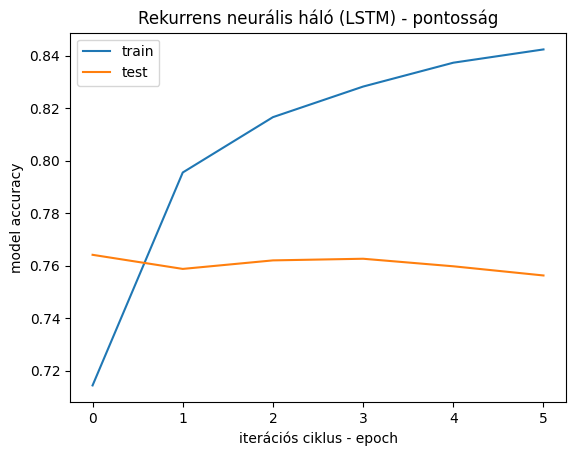

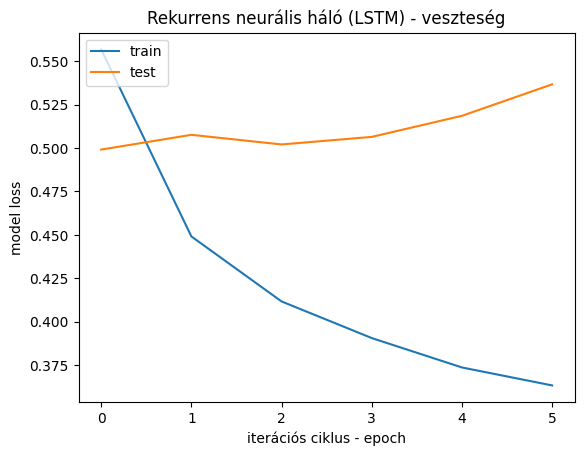

In [53]:
# LSTM Model teljesítmény - Chart
import matplotlib.pyplot as plt

plt.plot(snn_model_history.history['acc'])
plt.plot(snn_model_history.history['val_acc'])

plt.title('Rekurrens neurális háló (LSTM) - pontosság')
plt.ylabel('model accuracy')
plt.xlabel('iterációs ciklus - epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(snn_model_history.history['loss'])
plt.plot(snn_model_history.history['val_loss'])

plt.title('Rekurrens neurális háló (LSTM) - veszteség')
plt.ylabel('model loss')
plt.xlabel('iterációs ciklus - epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()


##A MODELLEK TELJESÍTMÉNYEINEK ÖSSZEHASONLÍTÁSA

In [54]:
# --- SNN ---
snn_train_acc = snn_model_history.history.get('accuracy', snn_model_history.history.get('acc'))[-1]
_, snn_test_acc = snn_model.evaluate(X_test, y_test, verbose=0)
snn_diff = snn_train_acc - snn_test_acc

# --- CNN ---
cnn_train_acc = cnn_model_history.history.get('accuracy', cnn_model_history.history.get('acc'))[-1]
_, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
cnn_diff = cnn_train_acc - cnn_test_acc

# --- LSTM ---
lstm_train_acc = lstm_model_history.history.get('accuracy', lstm_model_history.history.get('acc'))[-1]
_, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
lstm_diff = lstm_train_acc - lstm_test_acc

print("SNN  | Train Accuracy :", snn_train_acc)
print("SNN  | Test  Accuracy :", snn_test_acc)
print("SNN  | Difference     :", snn_diff)
print("-" * 40)
print("CNN  | Train Accuracy :", cnn_train_acc)
print("CNN  | Test  Accuracy :", cnn_test_acc)
print("CNN  | Difference     :", cnn_diff)
print("-" * 40)
print("LSTM | Train Accuracy :", lstm_train_acc)
print("LSTM | Test  Accuracy :", lstm_test_acc)
print("LSTM | Difference     :", lstm_diff)

SNN  | Train Accuracy : 0.8424062728881836
SNN  | Test  Accuracy : 0.7455000281333923
SNN  | Difference     : 0.09690624475479126
----------------------------------------
CNN  | Train Accuracy : 0.9504374861717224
CNN  | Test  Accuracy : 0.8500000238418579
CNN  | Difference     : 0.1004374623298645
----------------------------------------
LSTM | Train Accuracy : 0.8792187571525574
LSTM | Test  Accuracy : 0.8683000206947327
LSTM | Difference     : 0.010918736457824707


In [55]:
import time

# --- SNN timing ---
start = time.time()
_, snn_test_acc = snn_model.evaluate(X_test, y_test, verbose=0)
snn_time = time.time() - start
snn_train_acc = snn_model_history.history.get('accuracy', snn_model_history.history.get('acc'))[-1]
snn_diff = snn_train_acc - snn_test_acc

# --- CNN timing ---
start = time.time()
_, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
cnn_time = time.time() - start
cnn_train_acc = cnn_model_history.history.get('accuracy', cnn_model_history.history.get('acc'))[-1]
cnn_diff = cnn_train_acc - cnn_test_acc

# --- LSTM timing ---
start = time.time()
_, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
lstm_time = time.time() - start
lstm_train_acc = lstm_model_history.history.get('accuracy', lstm_model_history.history.get('acc'))[-1]
lstm_diff = lstm_train_acc - lstm_test_acc

print("SNN  | Train Accuracy :", snn_train_acc)
print("SNN  | Test  Accuracy :", snn_test_acc)
print("SNN  | Difference     :", snn_diff)
print("SNN  | Futásidő (s)  :", snn_time)
print("-" * 50)

print("CNN  | Train Accuracy :", cnn_train_acc)
print("CNN  | Test  Accuracy :", cnn_test_acc)
print("CNN  | Difference     :", cnn_diff)
print("CNN  | Futásidő (s)  :", cnn_time)
print("-" * 50)

print("LSTM | Train Accuracy :", lstm_train_acc)
print("LSTM | Test  Accuracy :", lstm_test_acc)
print("LSTM | Difference     :", lstm_diff)
print("LSTM | Futásidő (s)  :", lstm_time)

SNN  | Train Accuracy : 0.8424062728881836
SNN  | Test  Accuracy : 0.7455000281333923
SNN  | Difference     : 0.09690624475479126
SNN  | Futásidő (s)  : 0.9197278022766113
--------------------------------------------------
CNN  | Train Accuracy : 0.9504374861717224
CNN  | Test  Accuracy : 0.8500000238418579
CNN  | Difference     : 0.1004374623298645
CNN  | Futásidő (s)  : 3.7268450260162354
--------------------------------------------------
LSTM | Train Accuracy : 0.8792187571525574
LSTM | Test  Accuracy : 0.8683000206947327
LSTM | Difference     : 0.010918736457824707
LSTM | Futásidő (s)  : 14.86740255355835


In [56]:
import time
import pandas as pd

results = []

# --- SNN timing ---
start = time.time()
_, snn_test_acc = snn_model.evaluate(X_test, y_test, verbose=0)
snn_time = time.time() - start
snn_train_acc = snn_model_history.history.get('accuracy', snn_model_history.history.get('acc'))[-1]
snn_diff = snn_train_acc - snn_test_acc

results.append(["SNN", snn_train_acc, snn_test_acc, snn_diff, snn_time])


# --- CNN timing ---
start = time.time()
_, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
cnn_time = time.time() - start
cnn_train_acc = cnn_model_history.history.get('accuracy', cnn_model_history.history.get('acc'))[-1]
cnn_diff = cnn_train_acc - cnn_test_acc

results.append(["CNN", cnn_train_acc, cnn_test_acc, cnn_diff, cnn_time])


# --- LSTM timing ---
start = time.time()
_, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
lstm_time = time.time() - start
lstm_train_acc = lstm_model_history.history.get('accuracy', lstm_model_history.history.get('acc'))[-1]
lstm_diff = lstm_train_acc - lstm_test_acc

results.append(["LSTM", lstm_train_acc, lstm_test_acc, lstm_diff, lstm_time])


# --- Táblázat létrehozása ---
df_results = pd.DataFrame(
    results,
    columns=[
        "Modell",
        "Train accuracy",
        "Test accuracy",
        "Különbség (overfitting indikátor)",
        "Futásidő (s)"
    ]
)

print(df_results)

  Modell  Train accuracy  Test accuracy  Különbség (overfitting indikátor)  \
0    SNN        0.842406         0.7455                           0.096906   
1    CNN        0.950437         0.8500                           0.100437   
2   LSTM        0.879219         0.8683                           0.010919   

   Futásidő (s)  
0      0.774842  
1      4.467523  
2     15.509283  


In [57]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_prob = cnn_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4961
           1       0.83      0.88      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

ROC-AUC: 0.9310006420790641
Confusion Matrix:
 [[4084  877]
 [ 623 4416]]


=== Összefoglaló (macro átlagok) ===


,Model,Train_Acc,Test_Acc,Diff(Train-Test),Eval_Time_s,Precision_macro,Recall_macro,F1_macro,Support
0,SNN,0.8424,0.7455,0.0969,0.788,0.7455,0.7455,0.7455,10000.000000
1,CNN,0.9504,0.8500,0.1004,2.965,0.8510,0.8498,0.8498,10000.000000
2,LSTM,0.8792,0.8683,0.0109,14.798,0.8684,0.8682,0.8683,10000.000000



=== SNN | Classification report (precision / recall / f1 / support) ===


,precision,recall,f1-score,support
0,0.7431,0.7444,0.7437,4961
1,0.7479,0.7466,0.7472,5039
accuracy,0.7455,0.7455,0.7455,1
macro avg,0.7455,0.7455,0.7455,10000
weighted avg,0.7455,0.7455,0.7455,10000


<Figure size 460x420 with 0 Axes>

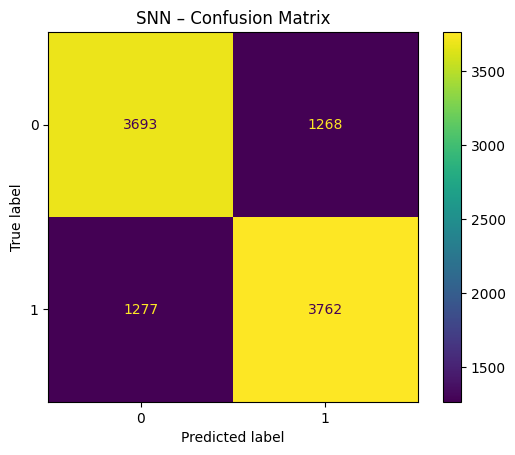


=== CNN | Classification report (precision / recall / f1 / support) ===


,precision,recall,f1-score,support
0,0.8676,0.8232,0.8448,4961
1,0.8343,0.8764,0.8548,5039
accuracy,0.8500,0.8500,0.8500,1
macro avg,0.8510,0.8498,0.8498,10000
weighted avg,0.8508,0.8500,0.8499,10000


<Figure size 460x420 with 0 Axes>

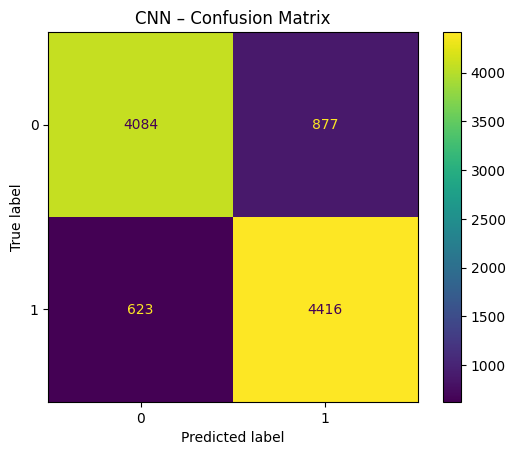


=== LSTM | Classification report (precision / recall / f1 / support) ===


,precision,recall,f1-score,support
0,0.8727,0.8599,0.8663,4961
1,0.8640,0.8766,0.8703,5039
accuracy,0.8683,0.8683,0.8683,1
macro avg,0.8684,0.8682,0.8683,10000
weighted avg,0.8684,0.8683,0.8683,10000


<Figure size 460x420 with 0 Axes>

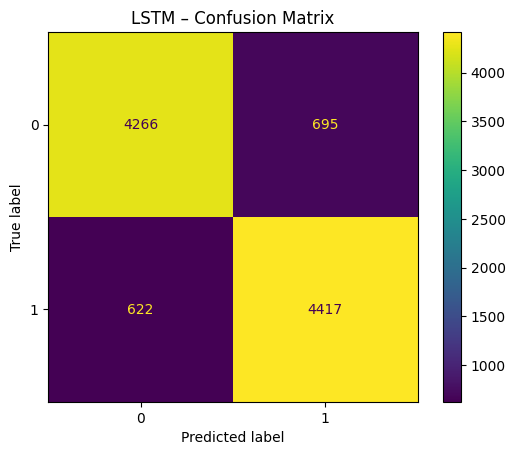

In [58]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def eval_binary_model(model, history, X_test, y_test, name, threshold=0.5):
    # --- timing (evaluate)
    t0 = time.time()
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    eval_time = time.time() - t0

    # --- train acc (last epoch) if available
    train_acc = None
    if history is not None:
        h = history.history
        train_acc = h.get("accuracy", h.get("acc", [None]))[-1]

    # --- predictions
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    # --- report + confusion
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # --- compact summary
    summary = {
        "Model": name,
        "Train_Acc": train_acc,
        "Test_Acc": test_acc,
        "Diff(Train-Test)": (train_acc - test_acc) if train_acc is not None else None,
        "Eval_Time_s": eval_time,
        "Precision_macro": rep["macro avg"]["precision"],
        "Recall_macro": rep["macro avg"]["recall"],
        "F1_macro": rep["macro avg"]["f1-score"],
        "Support": rep["macro avg"]["support"],
    }

    return summary, rep, cm

# --- Run evaluations ---
summaries = []
reports = {}
cms = {}

for name, model, hist in [
    ("SNN",  snn_model,  snn_model_history),
    ("CNN",  cnn_model,  cnn_model_history),
    ("LSTM", lstm_model, lstm_model_history),
]:
    s, r, cm = eval_binary_model(model, hist, X_test, y_test, name)
    summaries.append(s)
    reports[name] = r
    cms[name] = cm

# --- Pretty summary table ---
df = pd.DataFrame(summaries)
display_cols = [
    "Model", "Train_Acc", "Test_Acc", "Diff(Train-Test)", "Eval_Time_s",
    "Precision_macro", "Recall_macro", "F1_macro", "Support"
]
print("=== Összefoglaló (macro átlagok) ===")
display(df[display_cols].style.format({
    "Train_Acc": "{:.4f}",
    "Test_Acc": "{:.4f}",
    "Diff(Train-Test)": "{:.4f}",
    "Eval_Time_s": "{:.3f}",
    "Precision_macro": "{:.4f}",
    "Recall_macro": "{:.4f}",
    "F1_macro": "{:.4f}",
}))

# --- Per-model classification report (precision/recall/f1/support) + confusion matrix ---
for name in ["SNN", "CNN", "LSTM"]:
    print(f"\n=== {name} | Classification report (precision / recall / f1 / support) ===")
    rep_df = pd.DataFrame(reports[name]).T
    # rendezzük: osztályok (0,1), majd avg sorok
    order = [idx for idx in ["0", "1", "accuracy", "macro avg", "weighted avg"] if idx in rep_df.index]
    rep_df = rep_df.loc[order, ["precision", "recall", "f1-score", "support"]].copy()
    display(rep_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}",
    }))

    plt.figure(figsize=(4.6, 4.2))
    disp = ConfusionMatrixDisplay(confusion_matrix=cms[name], display_labels=[0, 1])
    disp.plot(values_format="d")
    plt.title(f"{name} – Confusion Matrix")
    plt.grid(False)
    plt.show()

In [59]:
print("Teljes adat:", len(y))
print("Train:", len(y_train))
print("Test:", len(y_test))
print("Confusion matrix sum:", cms["CNN"].sum())

Teljes adat: 50000
Train: 40000
Test: 10000
Confusion matrix sum: 10000


In [60]:
# A modell mentése h5 fájlként későbbi felhasználás céljából

lstm_model.save(f"./keszi_lstm_model_acc_{round(score[1], 3)}.h5", save_format='h5')

# Predikciók készítése élő IMDb adatok alapján

In [61]:
!ls # File-ok listázza a munkakönyvtárban

aclImdb
aclImdb_v1.tar.gz
glove.6B.100d.txt
IMDB_Dataset.csv
IMDb_ENG_SentimentAnalysis_with_NeuralNetwork.ipynb
IMDb_HUN_SentimentAnalysis_with_NeuralNetwork.ipynb
IMDb_letoltes_Stanfordrol.ipynb
IMDb_Unseen_Predictions.csv
IMDb_Unseen_Reviews.csv
keszi_lstm_model_acc_0.855.h5
keszi_lstm_model_acc_0.864.h5
keszi_lstm_model_acc_0.868.h5
lstm_model_acc_0.864.h5
Stanfordrol_lementett_ismeretlen_minta.csv


In [62]:
238
# # Korábban betanított LSTM modell betöltése

# from keras.models import load_model

# model_path ='./keszi_lstm_model_acc_0.856.h5'
# pretrained_lstm_model = load_model(model_path)

# # modell összegzése.
# pretrained_lstm_model.summary()

238

In [64]:
# IMDb-kritikák CSV-fájljának betöltése, amely ~6 filmkritikát tartalmaz, az IMDb-értékelésükkel együtt

sample_reviews = pd.read_csv("IMDb_Unseen_Reviews.csv")
#sample_reviews = pd.read_csv("Stanfordrol_lementett_ismeretlen_minta.csv")


sample_reviews.head(6)

,Unnamed: 0,Movie,Review Text,IMDb Rating
0,0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9
1,1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10
2,2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3
3,3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1
4,4,Eternals,Amazing visuals and philosophical concepts!\n\...,10
5,5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3


In [66]:
# Előfeldolgozási áttekintés szöveg a korábban definiált preprocess_text függvénnyel
unseen_reviews = sample_reviews['Review Text']

unseen_processed = []
for review in unseen_reviews:
  review = preprocess_text(review)
  unseen_processed.append(review)

In [67]:
# Tokenizáló példány korábban betanított tokenizálóval
unseen_tokenized = word_tokenizer.texts_to_sequences(unseen_processed)

# A pooling példány maximális hossza 100 token lehet
unseen_padded = pad_sequences(unseen_tokenized, padding='post', maxlen=maxlen)

In [68]:
# Tokenizált példány átadása az LSTM modellnek előrejelzésekhez
unseen_sentiments = lstm_model.predict(unseen_padded)

unseen_sentiments

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([[0.94475293],
       [0.994032  ],
       [0.29139498],
       [0.71402824],
       [0.96435565],
       [0.03527432]], dtype=float32)

In [69]:
# Modell kimeneti fájljának visszaírása a Google Drive-ra

sample_reviews['Predicted Sentiments'] = np.round(unseen_sentiments*10,1)

df_prediction_sentiments = pd.DataFrame(sample_reviews['Predicted Sentiments'], columns = ['Predicted Sentiments'])
df_movie                 = pd.DataFrame(sample_reviews['Movie'], columns = ['Movie'])
df_review_text           = pd.DataFrame(sample_reviews['Review Text'], columns = ['Review Text'])
df_imdb_rating           = pd.DataFrame(sample_reviews['IMDb Rating'], columns = ['IMDb Rating'])


dfx=pd.concat([df_movie, df_review_text, df_imdb_rating, df_prediction_sentiments], axis=1)

dfx.to_csv("./IMDb_Unseen_Predictions.csv", sep=',', encoding='UTF-8')

dfx.head(6)

,Movie,Review Text,IMDb Rating,Predicted Sentiments
0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9,9.4
1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10,9.9
2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3,2.9
3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1,7.1
4,Eternals,Amazing visuals and philosophical concepts!\n\...,10,9.6
5,Eternals,Worst MCU film ever\n\nFollowing the events of...,3,0.4


#Predikciók  ismeretlen IMDb adatokon - Stanford-ról beolvasva. Futásidő: 17 min 55 sec

---



In [70]:
# --- Stanford IMDb dataset letöltés + betöltés + első 6 sor megjelenítése ---

import os
import tarfile
import urllib.request
import pandas as pd

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

# 1️⃣ Letöltés
if not os.path.exists(filename):
    print("Downloading Stanford IMDb dataset...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")

# 2️⃣ Kicsomagolás
if not os.path.exists("aclImdb"):
    print("Extracting dataset...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete.")

# 3️⃣ Betöltés DataFrame-be
data = []
base_path = "aclImdb"

for split in ["train", "test"]:
    for sentiment in ["pos", "neg"]:
        path = os.path.join(base_path, split, sentiment)
        for file in os.listdir(path):
            if file.endswith(".txt"):
                rating = int(file.split("_")[1].split(".")[0])
                with open(os.path.join(path, file), encoding="utf-8") as f:
                    review = f.read()
                data.append({
                    "split": split,
                    "review": review,
                    "rating": rating,
                    "sentiment": sentiment
                })

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print("\nElső 6 sor:")
df.head(6)

Dataset shape: (50000, 4)

Első 6 sor:


,split,review,rating,sentiment
0,train,I will never forget this film or the events th...,10,pos
1,train,This was a really cool movie. It just goes to ...,8,pos
2,train,"A well cast summary of a real event! Well, act...",8,pos
3,train,I knew absolutely nothing about Chocolat befor...,8,pos
4,train,A THIEF IN THE NIGHT is an excellent fictional...,10,pos
5,train,This animated feature (a co-production between...,9,pos


In [71]:
df.tail(6)

,split,review,rating,sentiment
49994,test,This ultra-low budget kitchen-sink yawn is the...,1,neg
49995,test,It is unsettling seeing so many people giving ...,2,neg
49996,test,Well........how and where do I start to descri...,1,neg
49997,test,I watched this last nite with an open mind. So...,1,neg
49998,test,"I loved the first 15 minutes, and I loved some...",3,neg
49999,test,This film is about a mysterious love letter th...,4,neg


In [72]:
df.describe()

,rating
count,50000.000000
mean,5.495340
std,3.478721
min,1.000000
25%,2.000000
50%,5.500000
75%,9.000000
max,10.000000


In [73]:
sample_df = df.sample(n=10)
sample_df

,split,review,rating,sentiment
45736,test,"A cheesy ""B"" crime thriller of the early '50, ...",2,neg
27006,test,"As a huge fan of horror, I had given up on the...",10,pos
5446,train,On the day of the California Presidential Prim...,8,pos
49533,test,"'Bloody Birthday' is an odd and, at times, hum...",4,neg
17867,train,"My first review of 2010 is ""Into The Blue 2: T...",4,neg
27366,test,"As one who frequently goes to the movies, I ha...",10,pos
34093,test,"I didn't personally know Karen Carpenter, nor,...",8,pos
6787,train,This was a very well scripted movie. Great fun...,8,pos
20509,train,When Ritchie first burst on to movie scene his...,2,neg
22362,train,"I purchased this movie at a car boot sale, so ...",2,neg


In [74]:
import os
print(os.getcwd())

/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Sentiment


Mentsük le a drive-ba a kiválasztott tízes véletlen mintánkat. A lementett minta neve legyen Stanfordról lementett ismeretlen minta. és formátuma legyen CSV.

In [75]:
# --- 10 elemű véletlen minta mentése CSV-be a Drive-ra ---

from google.colab import drive
import pandas as pd

# Drive csatolása
drive.mount('/content/drive')

# 10 elemű véletlen minta
sample_df = df.sample(n=10)

# mentési útvonal
file_path = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Sentiment/Stanfordrol_lementett_ismeretlen_minta.csv"

# mentés CSV-be
sample_df.to_csv(file_path, index=False, encoding="utf-8")

print("✅ A minta elmentve ide:")
print(file_path)

# ellenőrzés
sample_df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ A minta elmentve ide:
/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Sentiment/Stanfordrol_lementett_ismeretlen_minta.csv


,split,review,rating,sentiment
38165,test,Right up (or down) there with Toys and Jurassi...,1,neg
32981,test,"Even after all these years, this remain ""a per...",10,pos
3475,train,I own this movie and have watched it several t...,10,pos
2247,train,This was surprisingly intelligent for a TV mov...,8,pos
33659,test,Mark Blankfield played Jekyll and Hyde.<br /><...,10,pos
48153,test,It is quite rare that a movie comes along that...,1,neg
31705,test,Every review I have read so far seems to have ...,8,pos
18071,train,"Well, i could nt get into the plot, but thats ...",3,neg
37997,test,"No,no,no. That is my advice to you if you are ...",2,neg
46411,test,I was hooked in by the premise that the show w...,2,neg


#Predikció végzése a fentiekben elmentett LSTM modellünkkel

Ebben a blokkban szereplő kód N=10 elemű véletlen mintát vesz a Stanford honlapról, fent letöltött df-ünkből és kiírja egymás mellé a split, review, rating, sentiment ÉS az LSTMmodellAlpjan Prediktalt oszlopokat. A lementett lstm modellünk - ami alapján predikátlunk - a Drive-unkban van, a jelen ipymb fiel mappájában, neve: keszi_lstm_model_acc_0.855.h5

In [76]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MODEL_PATH = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Sentiment/keszi_lstm_model_acc_0.855.h5"
model = load_model(MODEL_PATH)

MAXLEN = 100
VOCAB_SIZE = 92394  # az embedding paraméterekből becsülve (92394*100 = 9,239,400)

# N=10 minta
N = 10
sample_df = df.sample(n=N).reset_index(drop=True)
texts = sample_df["review"].astype(str).tolist()

# ÚJ tokenizer (⚠️ nem egyezik a tréning-tokenizerrel)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)  # ⚠️ még rosszabb, mert csak 10 szövegből tanul

seqs = tokenizer.texts_to_sequences(texts)
X = pad_sequences(seqs, maxlen=MAXLEN, padding="post", truncating="post")

preds = model.predict(X, verbose=0).reshape(-1)
# sigmoid, ha logit
if preds.min() < 0 or preds.max() > 1:
    preds = 1 / (1 + np.exp(-preds))

pred_label = np.where(preds >= 0.5, "pos", "neg")

out = sample_df.copy()
out["review_short"] = out["review"].str.replace(r"\s+", " ", regex=True).str.slice(0, 180) + "..."
out["LSTM_pred_prob_pos"] = np.round(preds.astype(float), 4)
out["LSTM_pred_label"] = pred_label

display(out[["split", "review_short", "rating", "sentiment", "LSTM_pred_prob_pos", "LSTM_pred_label"]])

,split,review_short,rating,sentiment,LSTM_pred_prob_pos,LSTM_pred_label
0,train,I *loved* the original Scary Movie. I'm a huge...,2,neg,0.1836,neg
1,test,In short this movie was awful.<br /><br />I un...,1,neg,0.0364,neg
2,test,I love most movies and I'm a big fan of Sean B...,1,neg,0.0851,neg
3,train,Houseboat Horror is a great title for this fil...,2,neg,0.4112,neg
4,test,"Without saying how it ended, it is sufficient ...",4,neg,0.6402,pos
5,train,Normally when I write a review for a movie onl...,1,neg,0.7806,pos
6,train,Michael Bowen plays an innocentish young man w...,10,pos,0.1948,neg
7,train,I got to say that Uma Thurman is the sexiest w...,8,pos,0.2813,neg
8,test,"Yeah, I know the girls are hot and the scenery...",3,neg,0.0412,neg
9,train,The statistics in this movie were well researc...,4,neg,0.0650,neg


In [77]:


import os, tarfile, urllib.request
import pandas as pd

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

# 1) Letöltés (ha még nincs meg)
if not os.path.exists(filename):
    print("Downloading...")
    urllib.request.urlretrieve(url, filename)
    print("Done.")

# 2) Csak 6 review beolvasása a tar.gz-ből (stream)
rows = []
need = 6

with tarfile.open(filename, "r:gz") as tar:
    for m in tar:
        # csak a review fájlok kellenek (pos/neg, train/test)
        if not m.isfile():
            continue
        name = m.name  # pl: aclImdb/train/pos/123_9.txt
        if not (name.startswith("aclImdb/train/pos/") or
                name.startswith("aclImdb/train/neg/") or
                name.startswith("aclImdb/test/pos/")  or
                name.startswith("aclImdb/test/neg/")):
            continue
        if not name.endswith(".txt"):
            continue

        parts = name.split("/")
        split = parts[1]          # train/test
        sentiment = parts[2]      # pos/neg
        fname = parts[-1]         # 123_9.txt
        rating = int(fname.split("_")[1].split(".")[0])

        f = tar.extractfile(m)
        text = f.read().decode("utf-8", errors="replace")

        rows.append({
            "split": split,
            "sentiment": sentiment,
            "rating": rating,
            "review": text
        })

        if len(rows) >= need:
            break

df6 = pd.DataFrame(rows)
print("Megjelenített sorok:", len(df6))
df6.head(6)

Megjelenített sorok: 6


,split,sentiment,rating,review
0,test,neg,3,I love sci-fi and am willing to put up with a ...
1,test,neg,4,"Worth the entertainment value of a rental, esp..."
2,test,neg,3,its a totally average film with a few semi-alr...
3,test,neg,2,STAR RATING: ***** Saturday Night **** Friday ...
4,test,neg,4,"First off let me say, If you haven't enjoyed a..."
5,test,neg,4,I had high hopes for this one until they chang...
